In [ ]:
%%capture
if 'google.colab' in str(get_ipython()):
    !pip install --upgrade xee

In [ ]:
!pip install rasterio -q

In [ ]:
import geopandas as gpd
import rasterio
import glob
import pandas as pd
import numpy as np
from rasterio.plot import show
from rasterio.mask import mask
from shapely.geometry import Point
from statsmodels.stats.outliers_influence import variance_inflation_factor
from tqdm import tqdm  # For progress tracking

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path1 = '/content/drive/MyDrive/Kamatira Model Data'
path2 = '/content/drive/MyDrive/Kamatira Model Data/GeoFiles/tree_ground_truths.geojson'
path3 = '/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson'
path4 = "/content/drive/MyDrive/Kamatira Model Data/2024_2025"
path5 = "/content/drive/MyDrive/Kamatira Model Data/Outputs/CHM"
path6 = "/content/drive/MyDrive/Kamatira Model Data/Outputs/DBH"

In [ ]:
import glob
import os
# Search for .tif files while excluding DEM and Slope
tif_files = [file for file in glob.glob(os.path.join(path4, '*.tif'))]

print("Filtered raster files for multicollinearity test:")
for file in tif_files:
    print(file)

Filtered raster files for multicollinearity test:


In [ ]:
# Load the ground truth data
path_ground_truth = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/GCPs_combined1.geojson"
gdf_points = gpd.read_file(path_ground_truth)
gdf_points.tail(5)

,H,geometry
65853,23.047567,POINT (35.2122 1.26635)
65854,25.648767,POINT (35.1802 1.2603)
65855,22.435934,POINT (35.16451 1.26632)
65856,34.301666,POINT (35.18797 1.26003)
65857,28.270599,POINT (35.21035 1.26517)


In [ ]:
import geopandas as gpd

# Load the ground truth data
path_ground_truth = "/content/drive/MyDrive/Kamatira Model Data/shapeFiles/Kamatira_Fitted_Dense_Points.shp"
gdf_idw = gpd.read_file(path_ground_truth)

# Rename 'grid_code' to 'H'
gdf_idw = gdf_idw.rename(columns={"grid_code": "H"})

# Keep only 'H' and 'geometry'
gdf_idw = gdf_idw[["H", "geometry"]]

# Randomly sample 30000 points
gdf_sampled = gdf_idw.sample(n=40000, random_state=42).reset_index(drop=True)

gdf_sampled.head()


,H,geometry
0,8.47569,POINT (35.23654 1.27336)
1,23.60200,POINT (35.22842 1.27032)
2,21.67550,POINT (35.16359 1.27917)
3,18.58200,POINT (35.1641 1.26305)
4,22.67320,POINT (35.22047 1.26643)


In [ ]:
gdf_sampled.tail()

,H,geometry
39995,18.3908,POINT (35.18343 1.25732)
39996,22.9452,POINT (35.15466 1.28023)
39997,28.3082,POINT (35.16717 1.26264)
39998,22.7033,POINT (35.20056 1.25964)
39999,25.4708,POINT (35.20543 1.26682)


In [ ]:
gdf_below_20 = gdf_sampled[gdf_sampled["H"] < 15]

# Display count and a sample
print(f"Number of points with H < 15: {len(gdf_below_20)}")
gdf_below_20.head()


Number of points with H < 15: 8921


,H,geometry
0,8.47569,POINT (35.23654 1.27336)
8,12.16030,POINT (35.21359 1.26049)
16,11.48970,POINT (35.22902 1.28786)
21,10.51950,POINT (35.23025 1.27471)
23,14.49540,POINT (35.20181 1.26597)


In [ ]:
import geopandas as gpd

# Merge (append) the two GeoDataFrames
gdf_merged = gpd.GeoDataFrame(pd.concat([gdf_below_20, gdf_points], ignore_index=True), crs=gdf_points.crs)

# Show result
print(f"Total number of merged points: {len(gdf_merged)}")
gdf_merged.head()


Total number of merged points: 74779


,H,geometry
0,8.47569,POINT (35.23654 1.27336)
1,12.16030,POINT (35.21359 1.26049)
2,11.48970,POINT (35.22902 1.28786)
3,10.51950,POINT (35.23025 1.27471)
4,14.49540,POINT (35.20181 1.26597)


In [ ]:
gdf_points=gdf_merged

In [ ]:
import pandas as pd

# Define the bins and labels
bins = [0, 10, 20, 30, 40, 50]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50']

# Cut 'H' into bins
gdf_points['H_bin'] = pd.cut(gdf_points['H'], bins=bins, labels=labels, right=True, include_lowest=True)

# Count how many points fall into each bin
h_bin_counts = gdf_points['H_bin'].value_counts().sort_index()

# Show the result
print(h_bin_counts)


H_bin
0-10      2977
11-20     6230
21-30    22206
31-40    42484
41-50      882
Name: count, dtype: int64


In [ ]:
import geopandas as gpd
import pandas as pd

# Ensure geometry is active
gdf_points = gdf_points.set_geometry("geometry")

# Define bins and sample sizes
sample_spec = {
      (0, 10):   2977,
      (11,20):  15217,
      (21, 30): 19206,
      (31, 40): 4571,
      (41,50):  882
}

sampled_frames = []

# Loop over the specified bins and sample sizes
for (low, high), size in sample_spec.items():
    subset = gdf_points[(gdf_points['H'] >= low) & (gdf_points['H'] <= high)]
    sample = subset.sample(n=min(size, len(subset)), random_state=42)
    sampled_frames.append(sample[["H", "geometry"]])  # Only keep 'H' and 'geometry'

# Combine all samples into one GeoDataFrame
gdf_sampled = pd.concat(sampled_frames, ignore_index=True)
gdf_sampled = gpd.GeoDataFrame(gdf_sampled, geometry="geometry")

# Display sample count by H range
print("Sampled point distribution by H bins:")
print(gdf_sampled["H"].groupby(pd.cut(gdf_sampled["H"], bins=[10, 20, 30, 40, 50])).count())

# Optional: Save to file
# gdf_sampled.to_file("sampled_points_by_H_range.geojson", driver="GeoJSON")


Sampled point distribution by H bins:
H
(10, 20]     4615
(20, 30]    19206
(30, 40]     4571
(40, 50]      375
Name: H, dtype: int64


/tmp/ipython-input-2534580554.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(gdf_sampled["H"].groupby(pd.cut(gdf_sampled["H"], bins=[10, 20, 30, 40, 50])).count())


In [ ]:
gdf_points=gdf_sampled
gdf_points.head(10)

,H,geometry
0,9.80404,POINT (35.23122 1.28588)
1,9.54544,POINT (35.2285 1.2748)
2,9.39924,POINT (35.23495 1.27144)
3,8.59655,POINT (35.22908 1.28424)
4,6.16901,POINT (35.23882 1.27297)
5,7.62000,POINT (35.23773 1.27217)
6,6.39292,POINT (35.17156 1.26575)
7,8.69468,POINT (35.23434 1.27346)
8,8.70109,POINT (35.23749 1.27115)
9,7.01079,POINT (35.17076 1.26695)


In [ ]:
gdf=gdf_points

In [ ]:
# Define source raster paths
raster_paths = {
    "NDVI_24_25": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2024_2025_resampled.tif",
    "EVI_24_25": "/content/drive/MyDrive/Kamatira Model Data/EVI_2024_2025_resampled.tif",
    # "RVI_24_25": "/content/drive/MyDrive/Kamatira Model Data/RVI_2024_2025.tif",
    "Rain_24_25": "/content/drive/MyDrive/Kamatira Model Data/Rainfall_2024_2025_resampled.tif",
    "VH_24_25": "/content/drive/MyDrive/Kamatira Model Data/S1_VH_2024_2025_resampled.tif",
    "VV_24_25": "/content/drive/MyDrive/Kamatira Model Data/S1_VV_2024_2025_resampled.tif",
    "LAI_24_25": "/content/drive/MyDrive/Kamatira Model Data/LAI_2024_2025.tif",
    "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
    "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
}


In [ ]:
import rasterio
import geopandas as gpd
import pandas as pd

# # Load the ground truth data
# path_ground_truth = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/GCPs_combined1.geojson"
# gdf_points = gpd.read_file(path_ground_truth)

def extract_raster_values(gdf, raster_paths):
    """
    Extracts raster values for given points from multiple raster files.
    """
    extracted_data = gdf.copy()

    for var, raster_path in raster_paths.items():
        with rasterio.open(raster_path) as src:
            values = list(src.sample([(point.x, point.y) for point in gdf.geometry]))
            extracted_data[var] = [val[0] if val is not None else None for val in values]

    # Ensure "H" column is retained
    if "H" in gdf.columns:
        extracted_data["H"] = gdf["H"]

    return extracted_data

# Extract data
gdf_rasters = extract_raster_values(gdf_points, raster_paths)

# Save the extracted data
output_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Coll_Kamatira_Extracted_Data.geojson"
gdf_rasters.to_file(output_path, driver="GeoJSON")

print("Extraction complete! Data saved at:", output_path)
print(gdf_rasters.head())  # Preview the first few rows

Extraction complete! Data saved at: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Coll_Kamatira_Extracted_Data.geojson
         H                  geometry  NDVI_24_25  EVI_24_25  Rain_24_25  \
0  9.80404  POINT (35.23122 1.28588)    0.657841   0.424781  368.166656   
1  9.54544    POINT (35.2285 1.2748)    0.633641   0.265177  466.833344   
2  9.39924  POINT (35.23495 1.27144)    0.556548   0.323079  532.750000   
3  8.59655  POINT (35.22908 1.28424)    0.464476   0.328239  438.083344   
4  6.16901  POINT (35.23882 1.27297)    0.642406   0.471042  510.333344   

    VH_24_25   VV_24_25  LAI_24_25      Slope   DEM  
0 -15.067088  -9.873224   2.977423   9.094641  1885  
1 -15.975617 -11.306777   3.306852  40.346184  2191  
2 -18.015917 -12.116583   2.405319  32.512516  2335  
3 -15.948416  -8.349776   1.844101  11.179986  1924  
4 -17.534702 -11.694671   2.948843  10.024988  2369  


In [ ]:
gdf_rasters.tail()

,H,geometry,NDVI_24_25,EVI_24_25,Rain_24_25,VH_24_25,VV_24_25,LAI_24_25,Slope,DEM
31739,42.218300,POINT (35.18506 1.2615),0.721227,0.426574,640.833313,-16.264048,-12.922010,3.620355,34.227581,2166
31740,41.308132,POINT (35.18984 1.26293),0.679377,0.349427,460.166656,-14.282973,-6.312459,3.530157,32.067070,2157
31741,41.614132,POINT (35.18531 1.26155),0.704509,0.401034,640.833313,-15.154576,-7.725158,3.534834,31.995079,2161
31742,41.636768,POINT (35.18422 1.25878),0.665533,0.329635,549.416687,-14.836319,-4.766653,3.386149,24.044718,2314
31743,42.840267,POINT (35.18931 1.26207),0.733166,0.467589,460.666656,-21.373411,-14.416782,3.968927,34.784702,2215


In [ ]:
# # Load the ground truth shapefile
# path_ground_truth = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Coll_Kamatira_Extracted_Data.geojson"
# gdf_points = gpd.read_file(path_ground_truth)


In [ ]:
# gdf_rasters=gdf_points
gdf_rasters.tail(2)

,H,geometry,NDVI_24_25,EVI_24_25,Rain_24_25,VH_24_25,VV_24_25,LAI_24_25,Slope,DEM
31742,41.636768,POINT (35.18422 1.25878),0.665533,0.329635,549.416687,-14.836319,-4.766653,3.386149,24.044718,2314
31743,42.840267,POINT (35.18931 1.26207),0.733166,0.467589,460.666656,-21.373411,-14.416782,3.968927,34.784702,2215


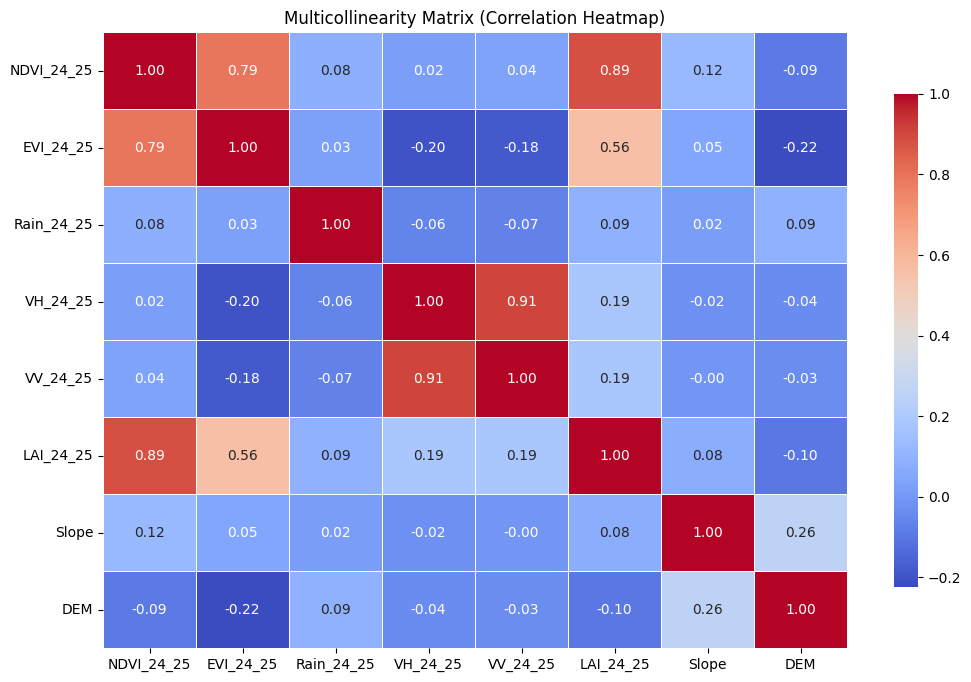

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the correlation matrix for all features in the DataFrame
corr_matrix = gdf_rasters.drop(columns=['geometry', 'H']).corr()

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title("Multicollinearity Matrix (Correlation Heatmap)")
plt.show()


In [ ]:
gdf_final=gdf_rasters
gdf_final.tail(3)

,H,geometry,NDVI_24_25,EVI_24_25,Rain_24_25,VH_24_25,VV_24_25,LAI_24_25,Slope,DEM
31741,41.614132,POINT (35.18531 1.26155),0.704509,0.401034,640.833313,-15.154576,-7.725158,3.534834,31.995079,2161
31742,41.636768,POINT (35.18422 1.25878),0.665533,0.329635,549.416687,-14.836319,-4.766653,3.386149,24.044718,2314
31743,42.840267,POINT (35.18931 1.26207),0.733166,0.467589,460.666656,-21.373411,-14.416782,3.968927,34.784702,2215


In [ ]:
bins = [0, 10, 20, 30, 40, 50]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50']

In [ ]:
gdf_final['H_binned'] = pd.cut(gdf_final['H'], bins=bins, labels=labels, right=False)

In [ ]:
bin_counts = gdf_final['H_binned'].value_counts().sort_index()
print(bin_counts)
gdf_final.head()

H_binned
0-10      2977
11-20     4615
21-30    19206
31-40     4571
41-50      375
Name: count, dtype: int64


,H,geometry,NDVI_24_25,EVI_24_25,Rain_24_25,VH_24_25,VV_24_25,LAI_24_25,Slope,DEM,H_binned
0,9.80404,POINT (35.23122 1.28588),0.657841,0.424781,368.166656,-15.067088,-9.873224,2.977423,9.094641,1885,0-10
1,9.54544,POINT (35.2285 1.2748),0.633641,0.265177,466.833344,-15.975617,-11.306777,3.306852,40.346184,2191,0-10
2,9.39924,POINT (35.23495 1.27144),0.556548,0.323079,532.750000,-18.015917,-12.116583,2.405319,32.512516,2335,0-10
3,8.59655,POINT (35.22908 1.28424),0.464476,0.328239,438.083344,-15.948416,-8.349776,1.844101,11.179986,1924,0-10
4,6.16901,POINT (35.23882 1.27297),0.642406,0.471042,510.333344,-17.534702,-11.694671,2.948843,10.024988,2369,0-10


In [ ]:
import pandas as pd

# Assuming gdf_final has a column 'height' with actual height values
# and you've created the H_binned column for categorization

# Filter for the 0-10 bin and get the 10 smallest values
lowest_10 = gdf_final[gdf_final['H_binned'] == '0-10'].nsmallest(10, 'H')
print(lowest_10[['H']])  # Show just the height values

            H
807   2.13360
2766  2.13360
2628  2.74320
2846  2.87878
1252  3.04800
1545  3.04800
2406  3.04800
1093  3.29241
272   3.39408
678   3.65383


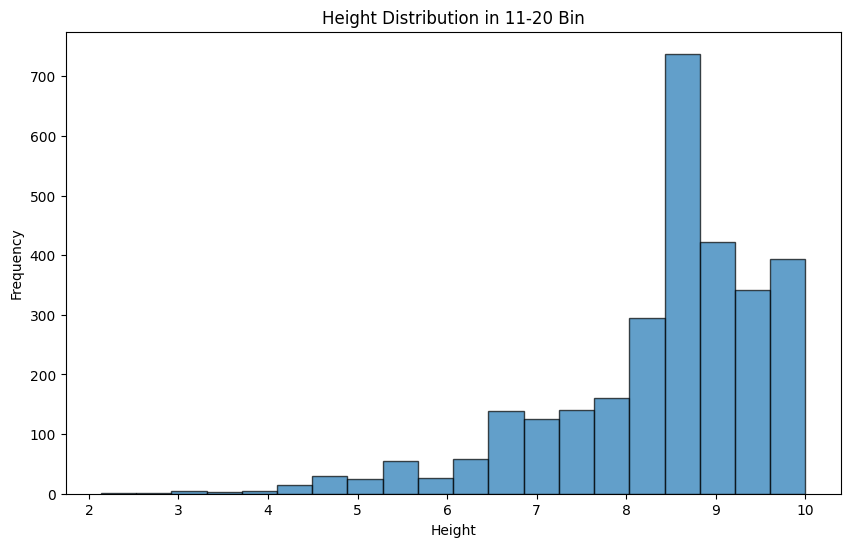

10 smallest values in 0-10 bin:
[2.1336  2.1336  2.7432  2.87878 3.048   3.048   3.048   3.29241 3.39408
 3.65383]


In [ ]:
import matplotlib.pyplot as plt

bin_0_10 = gdf_final[gdf_final['H_binned'] == '0-10']['H']
plt.figure(figsize=(10, 6))
plt.hist(bin_0_10, bins=20, alpha=0.7, edgecolor='black')
plt.title('Height Distribution in 11-20 Bin')
plt.xlabel('Height')
plt.ylabel('Frequency')
plt.show()

# Show the 10 smallest values
print("10 smallest values in 0-10 bin:")
print(bin_0_10.nsmallest(10).values)

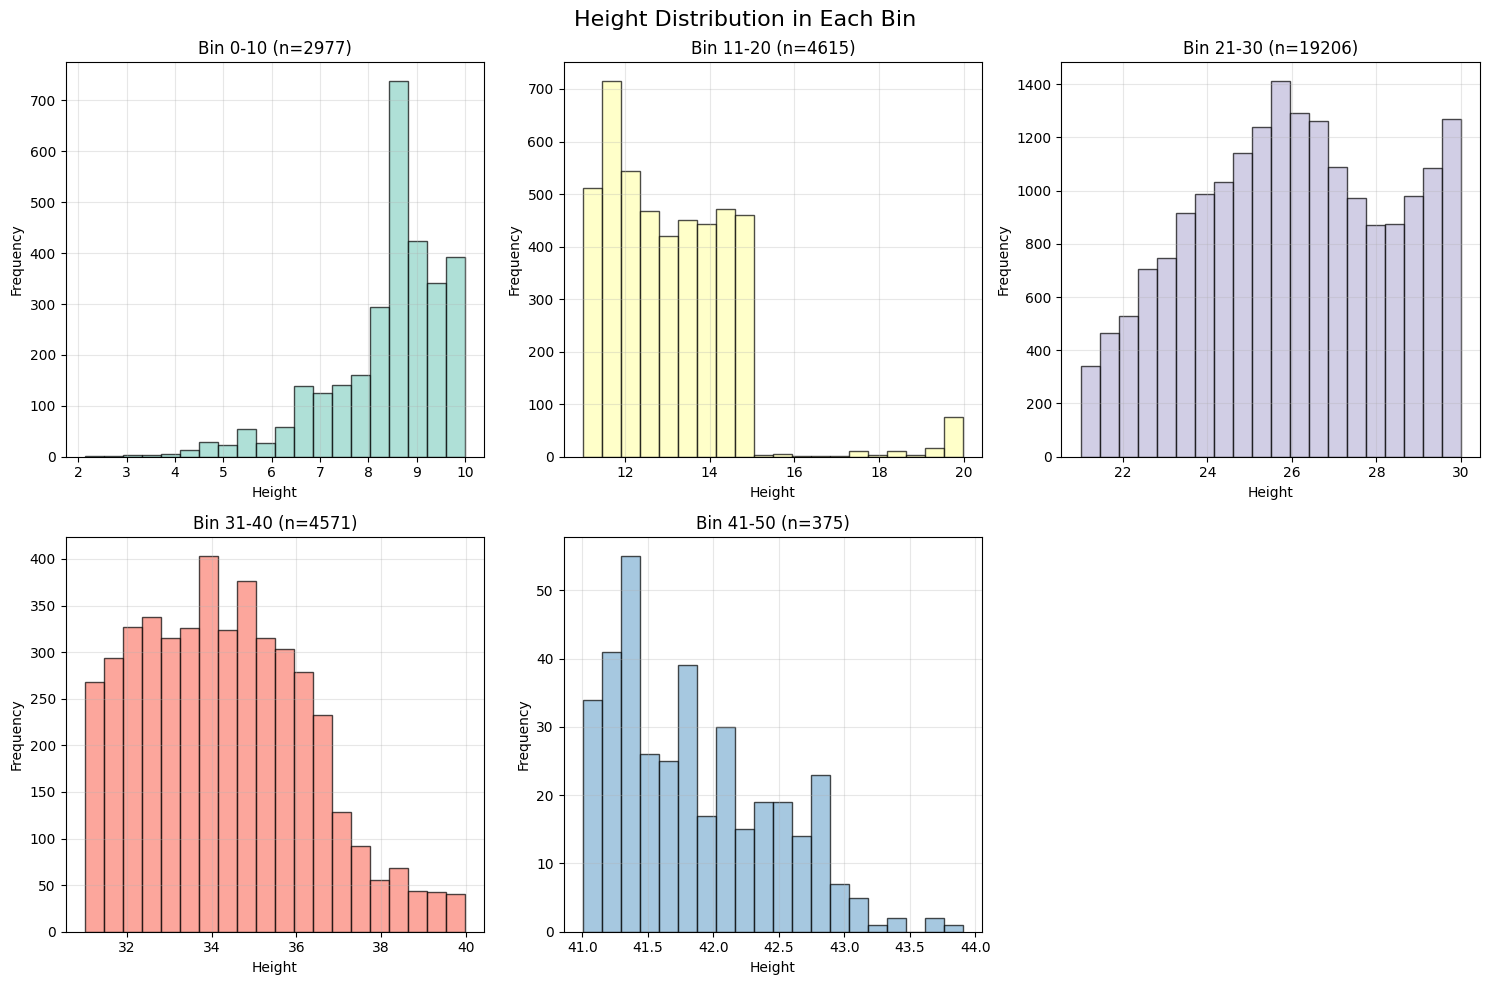

Summary Statistics by Bin:
--------------------------------------------------

Bin 0-10:
  Count: 2977
  Mean: 8.39
  Std: 1.21
  Min: 2.13
  Max: 10.00

Bin 11-20:
  Count: 4615
  Mean: 13.08
  Std: 1.55
  Min: 11.00
  Max: 19.99

Bin 21-30:
  Count: 19206
  Mean: 25.99
  Std: 2.34
  Min: 21.00
  Max: 30.00

Bin 31-40:
  Count: 4571
  Mean: 34.31
  Std: 1.99
  Min: 31.00
  Max: 39.99

Bin 41-50:
  Count: 375
  Mean: 41.85
  Std: 0.61
  Min: 41.00
  Max: 43.91


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create subplots for all bins
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Height Distribution in Each Bin', fontsize=16)
axes = axes.flatten()

# Define the bins
bins = ['0-10', '11-20', '21-30', '31-40', '41-50']

# Create histogram for each bin
for i, bin_name in enumerate(bins):
    # Filter data for each bin
    bin_data = gdf_final[gdf_final['H_binned'] == bin_name]['H']

    # Create histogram
    axes[i].hist(bin_data, bins=20, alpha=0.7, color=plt.cm.Set3(i), edgecolor='black')
    axes[i].set_title(f'Bin {bin_name} (n={len(bin_data)})')
    axes[i].set_xlabel('Height')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

# Hide the empty subplot (we have 5 bins but 6 subplot positions)
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

# Print summary statistics for each bin
print("Summary Statistics by Bin:")
print("-" * 50)
for bin_name in bins:
    bin_data = gdf_final[gdf_final['H_binned'] == bin_name]['H']
    print(f"\nBin {bin_name}:")
    print(f"  Count: {len(bin_data)}")
    print(f"  Mean: {bin_data.mean():.2f}")
    print(f"  Std: {bin_data.std():.2f}")
    print(f"  Min: {bin_data.min():.2f}")
    print(f"  Max: {bin_data.max():.2f}")

In [ ]:
# Quick implementation of strategic resampling
target_size = 5000
balanced_samples = []

for bin_name in gdf_final['H_binned'].unique():
    bin_data = gdf_final[gdf_final['H_binned'] == bin_name]

    if len(bin_data) > target_size:
        # Downsample
        sampled = bin_data.sample(target_size, random_state=42)
    else:
        # Oversample with replacement
        sampled = bin_data.sample(target_size, replace=True, random_state=42)

    balanced_samples.append(sampled)

balanced_df = pd.concat(balanced_samples).reset_index(drop=True)

# Verify balance
print("Balanced dataset distribution:")
print(balanced_df['H_binned'].value_counts())

Balanced dataset distribution:
H_binned
0-10     5000
11-20    5000
21-30    5000
31-40    5000
41-50    5000
Name: count, dtype: int64


In [ ]:
balanced_df.head()
gdf_final=balanced_df

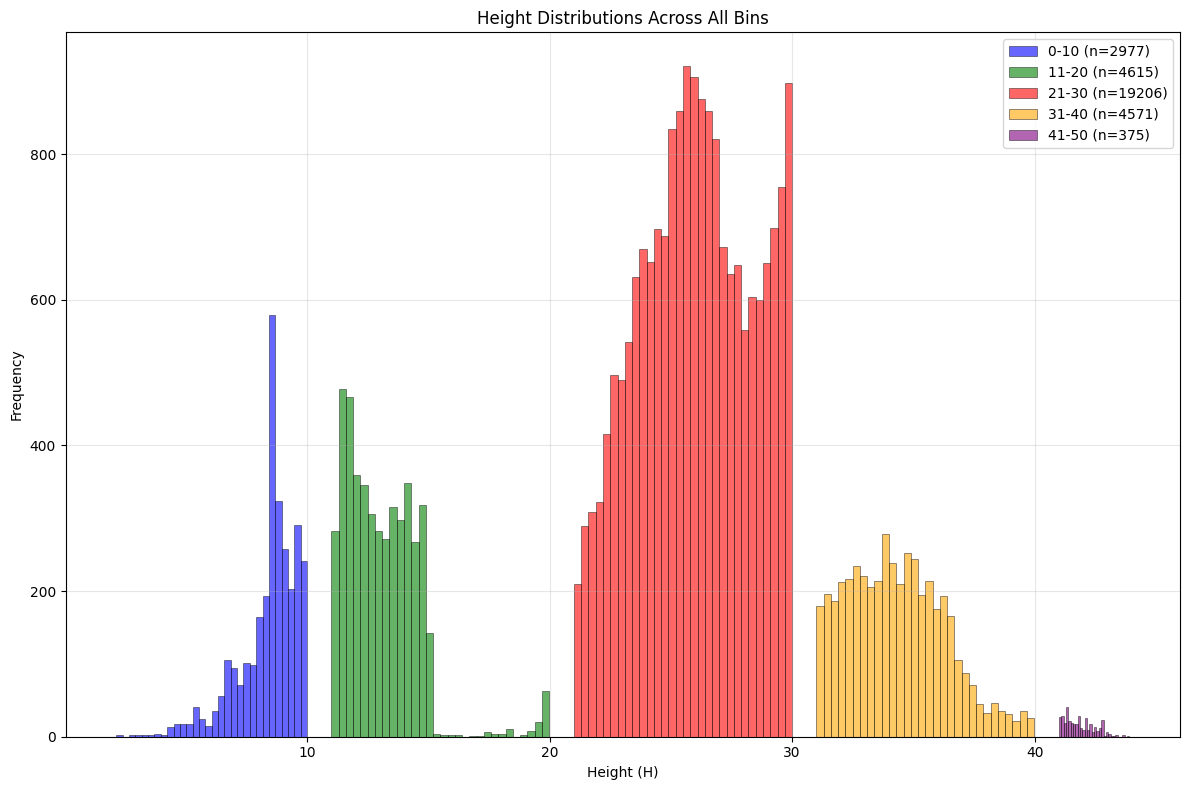

In [ ]:
# Overlay all distributions (normalized)
plt.figure(figsize=(12, 8))

colors = ['blue', 'green', 'red', 'orange', 'purple']
bins = ['0-10', '11-20', '21-30', '31-40', '41-50']

for i, (bin_name, color) in enumerate(zip(bins, colors)):
    bin_data = gdf_final[gdf_final['H_binned'] == bin_name]['H']
    plt.hist(bin_data, bins=30, alpha=0.6, label=f'{bin_name} (n={len(bin_data)})',
             color=color, edgecolor='black', linewidth=0.5)

plt.title('Height Distributions Across All Bins')
plt.xlabel('Height (H)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

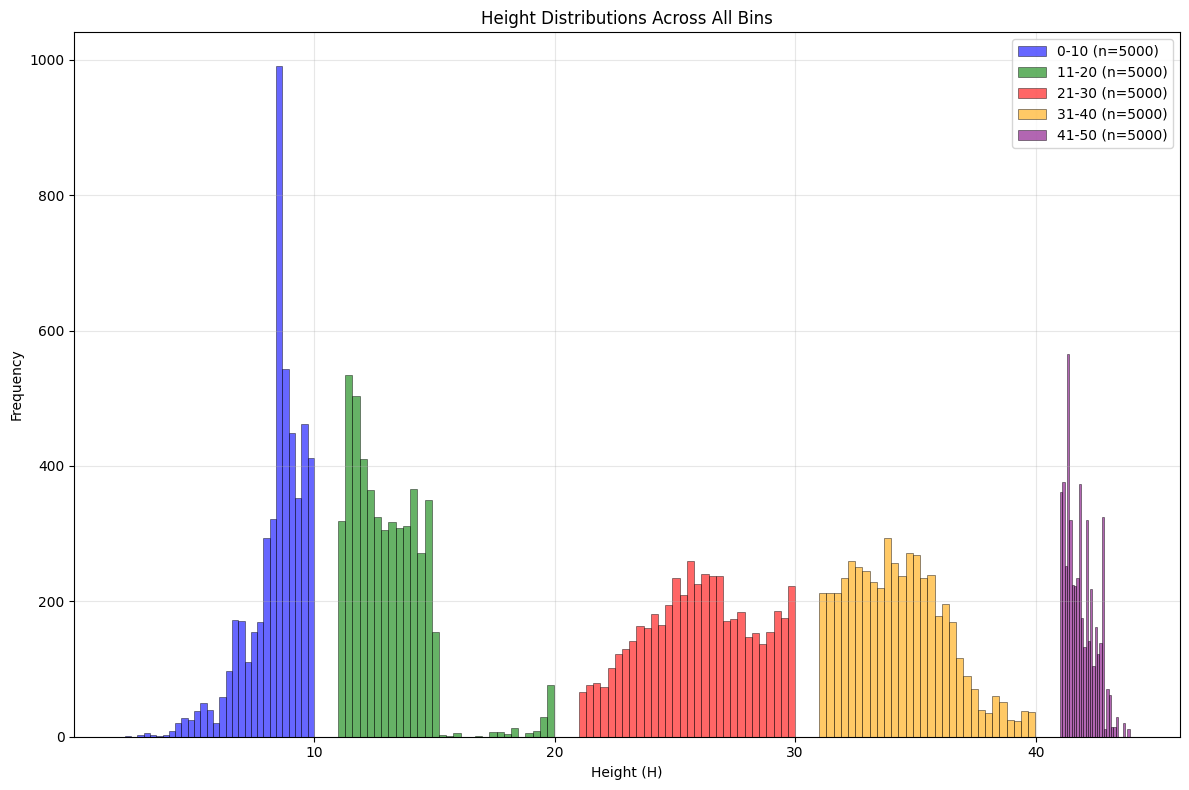

In [ ]:
# Overlay all distributions (normalized)
plt.figure(figsize=(12, 8))

colors = ['blue', 'green', 'red', 'orange', 'purple']
bins = ['0-10', '11-20', '21-30', '31-40', '41-50']

for i, (bin_name, color) in enumerate(zip(bins, colors)):
    bin_data = gdf_final[gdf_final['H_binned'] == bin_name]['H']
    plt.hist(bin_data, bins=30, alpha=0.6, label=f'{bin_name} (n={len(bin_data)})',
             color=color, edgecolor='black', linewidth=0.5)

plt.title('Height Distributions Across All Bins')
plt.xlabel('Height (H)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


CUDA available: True
GPU name: Tesla T4


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

# ----------------------------------------
# Prepare Data
# ----------------------------------------

df = gdf_final.drop(columns=["geometry"]).copy()

features = [
    "NDVI_24_25",
    "EVI_24_25",
    "LAI_24_25",
    "Rain_24_25",
    "Slope",
    "DEM"
]

X = df[features].fillna(df[features].mean()).astype(np.float32)
y = df["H"].astype(np.float32)

# ----------------------------------------
# Train/Test Split
# ----------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------------------
# GPU XGBoost (CORRECT API)
# ----------------------------------------

model = XGBRegressor(
    n_estimators=6000,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    objective="reg:squarederror",
    tree_method="hist",   # ✅ correct
    device="cuda",        # ✅ GPU enabled
    eval_metric="mae",
    random_state=42
)

model.fit(X_train, y_train, verbose=False)

# ----------------------------------------
# Evaluate
# ----------------------------------------

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


MAE: 3.5040078163146973
R²: 0.5850098133087158


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [21:56:36] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Remodell with Tuned params

In [ ]:
# ----------------------------------------
# 1. Imports
# ----------------------------------------
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
# ----------------------------------------
# 2. Prepare Data
# ----------------------------------------

# Drop geometry (GeoDataFrame → DataFrame)
df = gdf_final.drop(columns=["geometry"]).copy()

# Features and target
features = [
    "NDVI_24_25",
    "EVI_24_25",
    "LAI_24_25",
    "Rain_24_25",
    "Slope",
    "DEM"
]

X = df[features]
y = df["H"]

# Handle missing values
X = X.fillna(X.mean())


# ----------------------------------------
# 3. Handle Imbalance using Sample Weights
#    (Regression-safe approach)
# ----------------------------------------

# Inverse-frequency weights from height bins
bin_counts = df["H_binned"].value_counts()
weights_map = 1.0 / bin_counts
weights_map = weights_map / weights_map.mean()   # normalize

# Map weights to samples
sample_weights = df["H_binned"].map(weights_map)


# ----------------------------------------
# 4. Train / Test Split
# ----------------------------------------

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X,
    y,
    sample_weights,
    test_size=0.2,
    random_state=42
)


# ----------------------------------------
# 5. Train Optimized Random Forest
# ----------------------------------------

model = RandomForestRegressor(
    n_estimators=500,          # ↓ from 2000 (major speed-up)
    max_depth=25,              # prevents dominance of mid-heights
    min_samples_leaf=10,       # key for imbalance control
    min_samples_split=20,
    max_features="sqrt",
    bootstrap=True,
    n_jobs=-1,                 # use all CPU cores
    random_state=42
)

model.fit(
    X_train,
    y_train,
    sample_weight=w_train
)


# ----------------------------------------
# 6. Predictions
# ----------------------------------------

y_pred = model.predict(X_test)


# ----------------------------------------
# 7. Model Evaluation
# ----------------------------------------

# Overall metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Overall MAE: {mae:.3f}")
print(f"Overall R²: {r2:.3f}")

# Tail diagnostics (important!)
low_mask = y_test < 15
high_mask = y_test > 40

if low_mask.sum() > 0:
    print("Low-height MAE (H < 15 m):",
          mean_absolute_error(y_test[low_mask], y_pred[low_mask]))

if high_mask.sum() > 0:
    print("High-height MAE (H > 40 m):",
          mean_absolute_error(y_test[high_mask], y_pred[high_mask]))


# ----------------------------------------
# 8. Feature Importance (optional but useful)
# ----------------------------------------

feature_importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\nFeature Importance:")
print(feature_importance)


# # ----------------------------------------
# # 9. Save Model
# # ----------------------------------------

# model_path = "/content/drive/MyDrive/Kamatira Model Data/Models/RandomForest_H_Model_balanced_fast.pkl"
# joblib.dump(model, model_path)

# print(f"\nModel saved to: {model_path}")


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


Overall MAE: 2.494
Overall R²: 0.509
Low-height MAE (H < 15 m): 10.78207444780232
High-height MAE (H > 40 m): 2.8259574757797954

Feature Importance:
LAI_24_25     0.276976
Slope         0.166565
DEM           0.158040
NDVI_24_25    0.157599
Rain_24_25    0.150816
EVI_24_25     0.090004
dtype: float64

Model saved to: /content/drive/MyDrive/Kamatira Model Data/Models/RandomForest_H_Model_balanced_fast.pkl


In [ ]:
import lightgbm as lgb
import xgboost as xgb

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

# Import models
import lightgbm as lgb
import xgboost as xgb

# Convert GeoDataFrame to DataFrame (drop geometry)
df = gdf_final.drop(columns=["geometry"])

# Define input features (X) and target variable (y)
X = df[["NDVI_24_25", "EVI_24_25", "LAI_24_25", "Rain_24_25", "Slope", "DEM"]]
y = df["H"]

# Handle missing values (if any)
X = X.fillna(X.mean())

# Split data into training & testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- LightGBM ---
lgb_model = lgb.LGBMRegressor(n_estimators=300, random_state=42)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

# Evaluate LightGBM
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
r2_lgb = r2_score(y_test, y_pred_lgb)
print(f"LightGBM - MAE: {mae_lgb}")
print(f"LightGBM - R²: {r2_lgb}")

# Save LightGBM model
joblib.dump(lgb_model, "/content/drive/MyDrive/Kamatira Model Data/Models/LightGBM_H_Model.pkl")
print("LightGBM model saved!")

# --- XGBoost ---
xgb_model = xgb.XGBRegressor(n_estimators=300, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate XGBoost
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"XGBoost - MAE: {mae_xgb}")
print(f"XGBoost - R²: {r2_xgb}")

# Save XGBoost model
joblib.dump(xgb_model, "/content/drive/MyDrive/Kamatira Model Data/Models/XGBoost_H_Model.pkl")
print("XGBoost model saved!")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001492 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 20372, number of used features: 6
[LightGBM] [Info] Start training from score 29.183493
LightGBM - MAE: 2.8029946176416085
LightGBM - R²: 0.49876391027502365
LightGBM model saved!
XGBoost - MAE: 2.59282723612746
XGBoost - R²: 0.5219312301596231
XGBoost model saved!


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# LightGBM parameter grid
lgb_param_grid = {
    'num_leaves': [31, 50, 70],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300, 500],
    'max_depth': [-1, 10, 20],
    'min_child_samples': [20, 50, 100]
}

# XGBoost parameter grid
xgb_param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 6, 10],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

In [ ]:
# Grid search for LightGBM
lgb_grid = GridSearchCV(
    estimator=lgb.LGBMRegressor(random_state=42),
    param_grid=lgb_param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)
lgb_grid.fit(X_train, y_train)
print("Best LightGBM Params:", lgb_grid.best_params_)

# Grid search for XGBoost
xgb_grid = GridSearchCV(
    estimator=xgb.XGBRegressor(random_state=42),
    param_grid=xgb_param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)
xgb_grid.fit(X_train, y_train)
print("Best XGBoost Params:", xgb_grid.best_params_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001195 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 20372, number of used features: 6
[LightGBM] [Info] Start training from score 29.183493
Best LightGBM Params: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 500, 'num_leaves': 70}
Fitting 5 folds for each of 729 candidates, totalling 3645 fits
Best XGBoost Params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.8}


In [ ]:
# Best LightGBM
best_lgb = lgb_grid.best_estimator_
y_pred_lgb = best_lgb.predict(X_test)
print("Optimized LightGBM MAE:", mean_absolute_error(y_test, y_pred_lgb))
print("Optimized LightGBM R2:", r2_score(y_test, y_pred_lgb))

# Best XGBoost
best_xgb = xgb_grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
print("Optimized XGBoost MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("Optimized XGBoost R2:", r2_score(y_test, y_pred_xgb))

Optimized LightGBM MAE: 2.5283887141236505
Optimized LightGBM R2: 0.5502481471746332
Optimized XGBoost MAE: 2.34134230850034
Optimized XGBoost R2: 0.5575656702365563


Sample Stratification and Weighting

Random Forest Model Performance:
Training R²: 0.9193
Testing R²: 0.8545
Training RMSE: 3.5920
Testing RMSE: 4.8581
Testing MAE: 3.2456

Cross-validation R² scores: [-111.15653674  -58.82728722  -14.91201375  -32.08332963 -358.5894564 ]
Mean CV R²: -115.1137 (+/- 252.0297)

Feature Importance:
------------------------------
LAI_24_25: 0.5510
DEM: 0.1797
Rain_24_25: 0.0796
Slope: 0.0750
EVI_24_25: 0.0744
NDVI_24_25: 0.0403


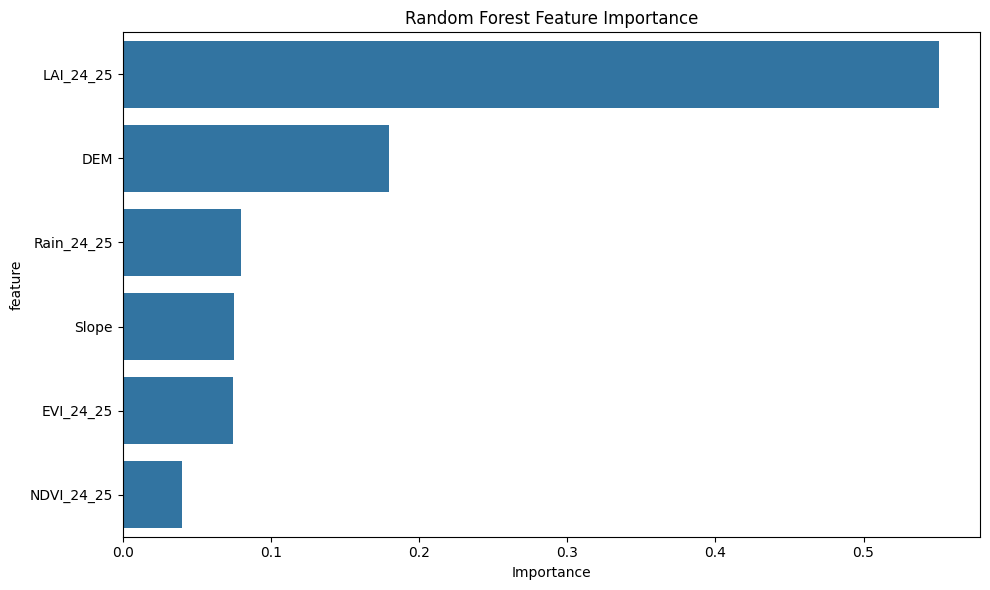

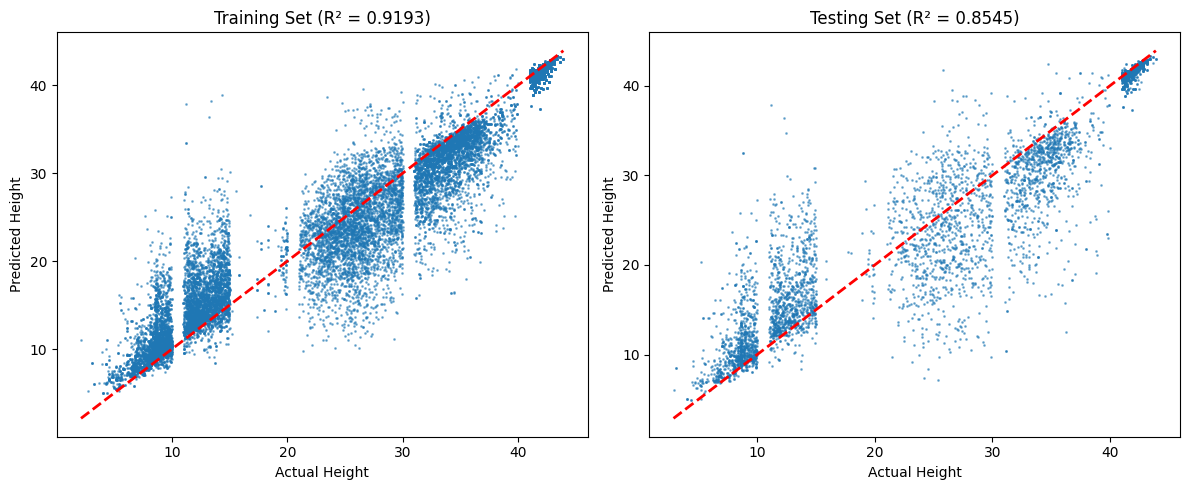

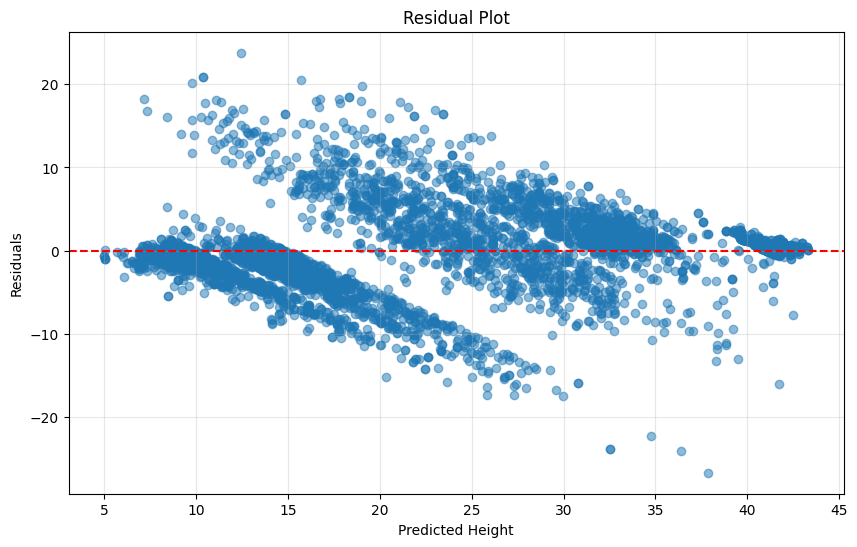

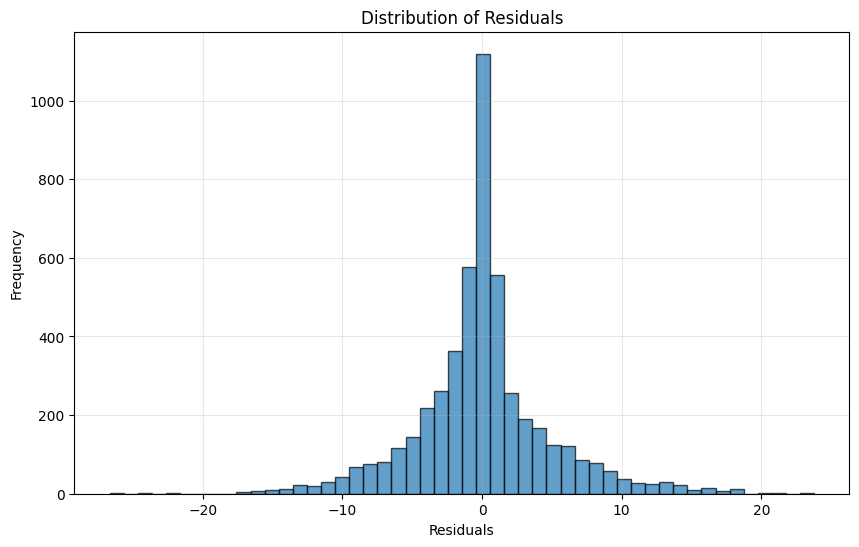

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Define features and target
features = [
    "NDVI_24_25",
    "EVI_24_25",
    "LAI_24_25",
    "Rain_24_25",
    "Slope",
    "DEM"
]

target = "H"

# Prepare data
X = gdf_final[features]
y = gdf_final[target]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

# Fit the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# Calculate metrics
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae = mean_absolute_error(y_test, y_pred_test)

print("Random Forest Model Performance:")
print("=" * 40)
print(f"Training R²: {train_r2:.4f}")
print(f"Testing R²: {test_r2:.4f}")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Testing RMSE: {test_rmse:.4f}")
print(f"Testing MAE: {test_mae:.4f}")

# Cross-validation
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')
print(f"\nCross-validation R² scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print("-" * 30)
for idx, row in feature_importance.iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Plot predictions vs actual
plt.figure(figsize=(12, 5))

# Training set
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_train, alpha=0.5, s=1)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual Height')
plt.ylabel('Predicted Height')
plt.title(f'Training Set (R² = {train_r2:.4f})')

# Testing set
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test, alpha=0.5, s=1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Height')
plt.ylabel('Predicted Height')
plt.title(f'Testing Set (R² = {test_r2:.4f})')

plt.tight_layout()
plt.show()

# Residual plot
residuals = y_test - y_pred_test
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Height')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)
plt.show()

# Distribution of residuals
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.grid(True, alpha=0.3)
plt.show()

Parameter Tuning-Optional

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 5, 10]
}

# Grid search with cross-validation
rf_grid = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    rf_grid,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit grid search (this will take some time)
print("Performing grid search...")
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:")
print(grid_search.best_params_)
print(f"Best CV score: {grid_search.best_score_:.4f}")

# Use best model
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
best_r2 = r2_score(y_test, y_pred_best)
print(f"Best model test R²: {best_r2:.4f}")

Performing grid search...
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Best CV score: 0.8534
Best model test R²: 0.8844



Training Random Forest...
Random Forest Results:
  Training R²: 0.9193
  Testing R²: 0.8545
  Testing RMSE: 4.8581
  Testing MAE: 3.2456

Training XGBoost...
XGBoost Results:
  Training R²: 0.8866
  Testing R²: 0.8360
  Testing RMSE: 5.1568
  Testing MAE: 3.6126

Training SVM...
SVM Results:
  Training R²: -0.0063
  Testing R²: -0.0069
  Testing RMSE: 12.7789
  Testing MAE: 11.3568

MODEL COMPARISON
        Model   Test R²  Test RMSE  Test MAE
Random Forest  0.854479   4.858062  3.245557
      XGBoost  0.836028   5.156850  3.612589
          SVM -0.006900  12.778894 11.356815


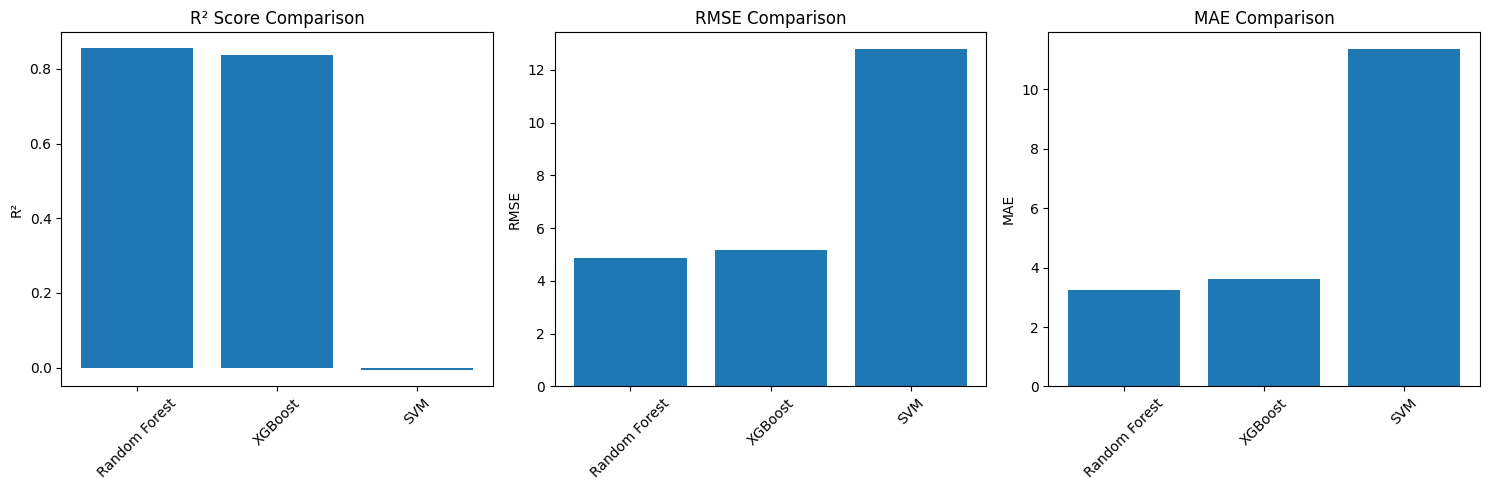

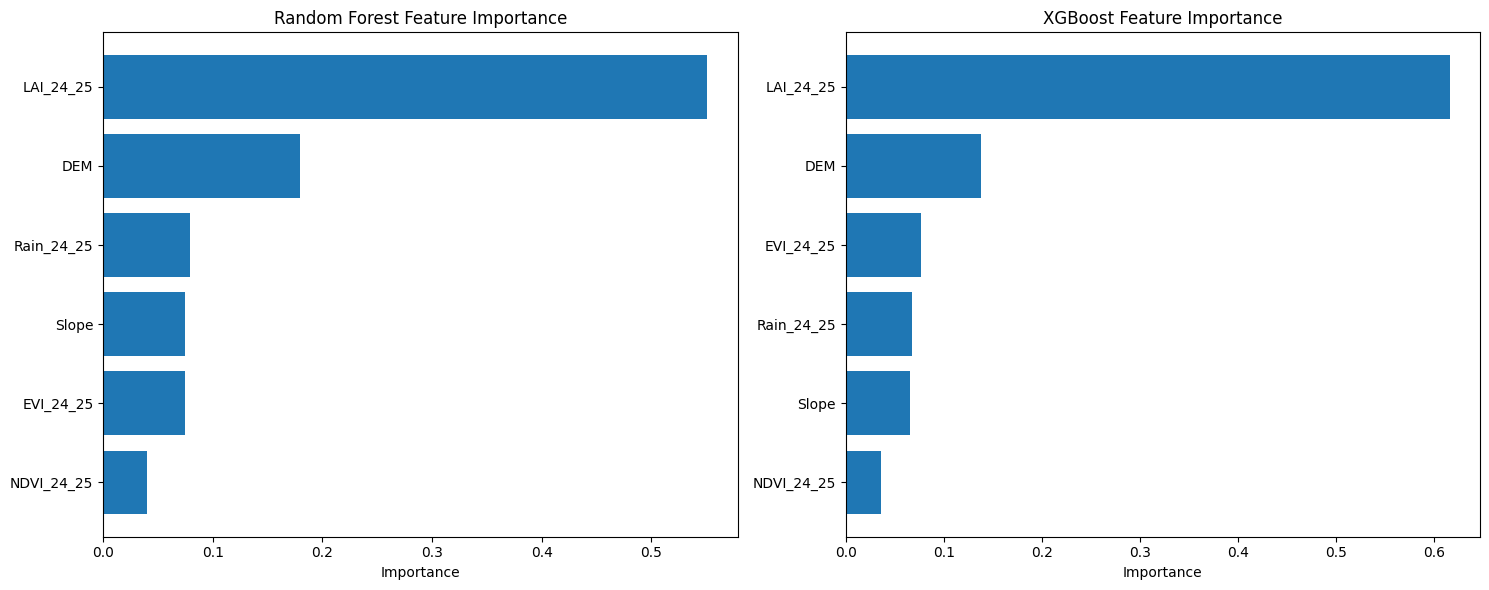

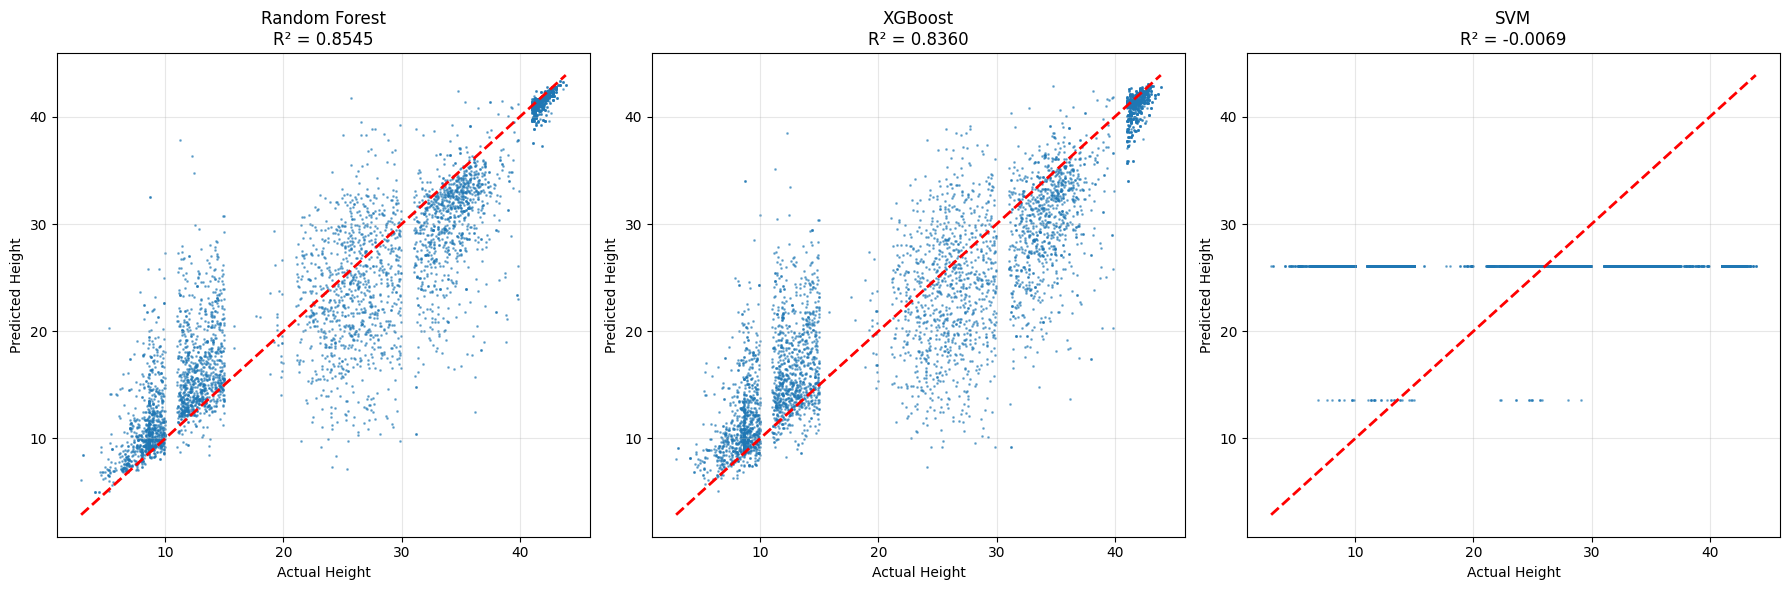

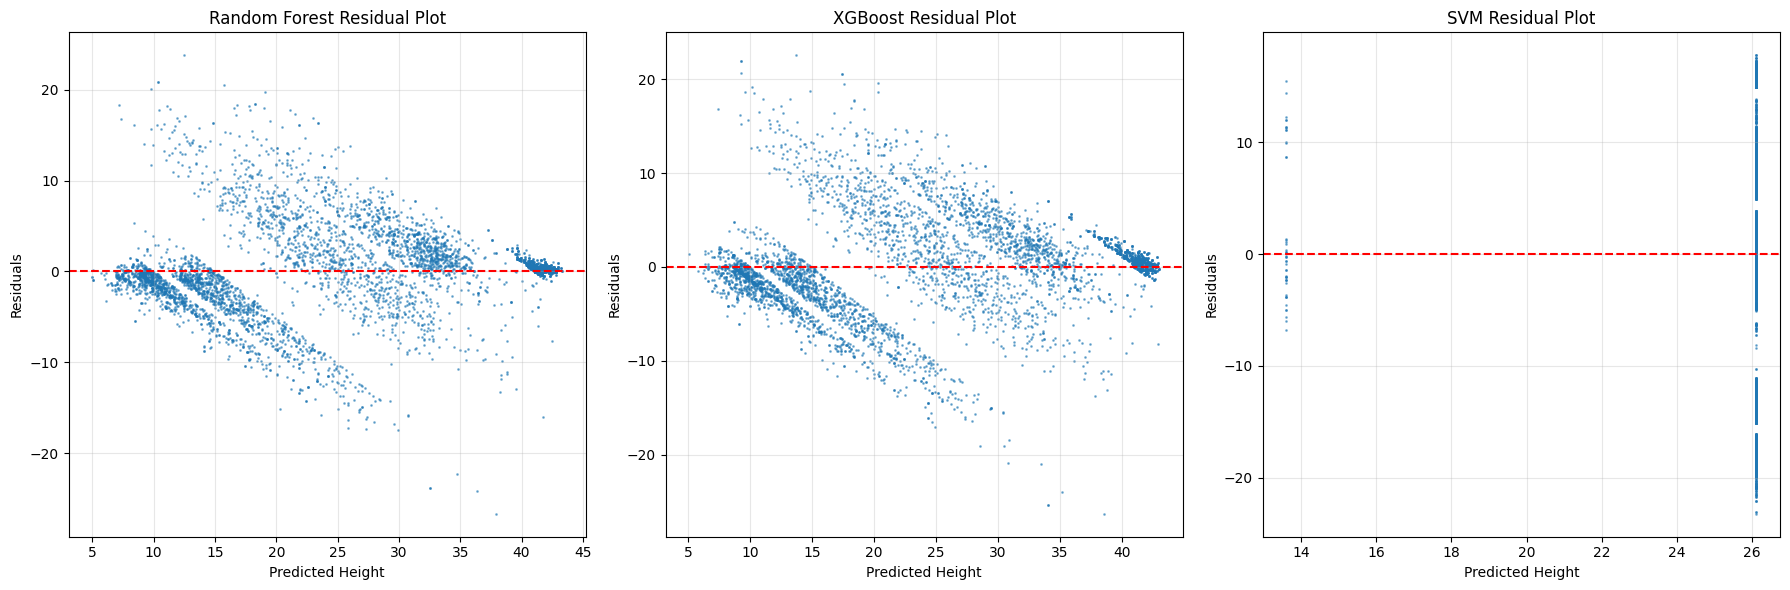


Best performing model: Random Forest
Test R²: 0.8545
Test RMSE: 4.8581
Test MAE: 3.2456


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Define features and target
features = [
    "NDVI_24_25",
    "EVI_24_25",
    "LAI_24_25",
    "Rain_24_25",
    "Slope",
    "DEM"
]

target = "H"

# Prepare data
X = gdf_final[features]
y = gdf_final[target]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize models
models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    ),
    'SVM': SVR(
        kernel='rbf',
        C=1.0,
        gamma='scale'
    )
}

# Train and evaluate models
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Calculate metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)

    # Store results
    results[name] = {
        'model': model,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'y_pred_test': y_pred_test
    }

    print(f"{name} Results:")
    print(f"  Training R²: {train_r2:.4f}")
    print(f"  Testing R²: {test_r2:.4f}")
    print(f"  Testing RMSE: {test_rmse:.4f}")
    print(f"  Testing MAE: {test_mae:.4f}")

# Compare all models
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test R²': [results[name]['test_r2'] for name in results.keys()],
    'Test RMSE': [results[name]['test_rmse'] for name in results.keys()],
    'Test MAE': [results[name]['test_mae'] for name in results.keys()]
})

comparison_df = comparison_df.sort_values('Test R²', ascending=False)
print(comparison_df.to_string(index=False))

# Plot comparison
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# R² comparison
ax1.bar(comparison_df['Model'], comparison_df['Test R²'])
ax1.set_title('R² Score Comparison')
ax1.set_ylabel('R²')
ax1.tick_params(axis='x', rotation=45)

# RMSE comparison
ax2.bar(comparison_df['Model'], comparison_df['Test RMSE'])
ax2.set_title('RMSE Comparison')
ax2.set_ylabel('RMSE')
ax2.tick_params(axis='x', rotation=45)

# MAE comparison
ax3.bar(comparison_df['Model'], comparison_df['Test MAE'])
ax3.set_title('MAE Comparison')
ax3.set_ylabel('MAE')
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Feature importance for tree-based models
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Random Forest feature importance
rf_importance = pd.DataFrame({
    'feature': features,
    'importance': results['Random Forest']['model'].feature_importances_
}).sort_values('importance', ascending=True)

axes[0].barh(rf_importance['feature'], rf_importance['importance'])
axes[0].set_title('Random Forest Feature Importance')
axes[0].set_xlabel('Importance')

# XGBoost feature importance
xgb_importance = pd.DataFrame({
    'feature': features,
    'importance': results['XGBoost']['model'].feature_importances_
}).sort_values('importance', ascending=True)

axes[1].barh(xgb_importance['feature'], xgb_importance['importance'])
axes[1].set_title('XGBoost Feature Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

# Prediction vs Actual plots for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (name, result) in enumerate(results.items()):
    axes[idx].scatter(y_test, result['y_pred_test'], alpha=0.5, s=1)
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[idx].set_xlabel('Actual Height')
    axes[idx].set_ylabel('Predicted Height')
    axes[idx].set_title(f'{name}\nR² = {result["test_r2"]:.4f}')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residual plots for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (name, result) in enumerate(results.items()):
    residuals = y_test - result['y_pred_test']
    axes[idx].scatter(result['y_pred_test'], residuals, alpha=0.5, s=1)
    axes[idx].axhline(y=0, color='r', linestyle='--')
    axes[idx].set_xlabel('Predicted Height')
    axes[idx].set_ylabel('Residuals')
    axes[idx].set_title(f'{name} Residual Plot')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary of best performing model
best_model_name = comparison_df.iloc[0]['Model']
print(f"\nBest performing model: {best_model_name}")
print(f"Test R²: {comparison_df.iloc[0]['Test R²']:.4f}")
print(f"Test RMSE: {comparison_df.iloc[0]['Test RMSE']:.4f}")
print(f"Test MAE: {comparison_df.iloc[0]['Test MAE']:.4f}")

In [ ]:
# Analyze performance across different height ranges
height_bins = pd.cut(y_test, bins=[0, 10, 20, 30, 40, 50],
                     labels=['0-10', '11-20', '21-30', '31-40', '41-50'])

print("\nPerformance by Height Bins:")
print("="*60)

for name, result in results.items():
    print(f"\n{name}:")
    y_pred = result['y_pred_test']

    bin_performance = []
    for bin_label in ['0-10', '11-20', '21-30', '31-40', '41-50']:
        mask = (height_bins == bin_label)
        if mask.sum() > 0:
            bin_r2 = r2_score(y_test[mask], y_pred[mask])
            bin_mae = mean_absolute_error(y_test[mask], y_pred[mask])
            bin_performance.append({
                'Bin': bin_label,
                'Count': mask.sum(),
                'R²': bin_r2,
                'MAE': bin_mae
            })

    bin_df = pd.DataFrame(bin_performance)
    print(bin_df.to_string(index=False))


Performance by Height Bins:

Random Forest:
  Bin  Count         R²      MAE
 0-10   1021 -10.468232 2.664071
11-20   1000 -11.087710 3.971830
21-30    985  -6.208034 4.895996
31-40    989  -7.491729 4.253455
41-50   1005  -0.404483 0.504192

XGBoost:
  Bin  Count         R²      MAE
 0-10   1021 -12.990329 3.106689
11-20   1000 -12.480212 4.269828
21-30    985  -6.791448 5.185936
31-40    989  -8.345568 4.604889
41-50   1005  -4.031344 0.954035

SVM:
  Bin  Count          R²       MAE
 0-10   1021 -215.604249 17.615144
11-20   1000  -66.518277 12.767659
21-30    985   -0.349809  2.055331
31-40    989  -17.606738  8.287256
41-50   1005 -633.399875 15.732096


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a pipeline that first scales the data, then fits the SVM
svm_model_scaled = make_pipeline(
    StandardScaler(),  # This scales all features to mean=0 and std=1
    SVR(kernel='rbf', C=1.0, gamma='scale')
)

# Now train it on the same data
svm_model_scaled.fit(X_train, y_train)
y_pred_svm_scaled = svm_model_scaled.predict(X_test)

# Evaluate
svm_r2_scaled = r2_score(y_test, y_pred_svm_scaled)
print(f"SVM (with Scaling) R²: {svm_r2_scaled:.4f}")

SVM (with Scaling) R²: 0.6400


Training samples: 20000
Testing samples: 5000
Features: ['NDVI_24_25', 'EVI_24_25', 'LAI_24_25', 'Rain_24_25', 'Slope', 'DEM']
Target range: [2.13, 43.91]

Training Random Forest...
Random Forest Results:
  Training R²: 0.9193
  Testing R²: 0.8545
  R² Difference: 0.0648
  5-Fold CV R²: 0.8379 ± 0.0063
  Testing RMSE: 4.8581
  Testing MAE: 3.2456

Training XGBoost...
XGBoost Results:
  Training R²: 0.8872
  Testing R²: 0.8353
  R² Difference: 0.0519
  5-Fold CV R²: 0.8274 ± 0.0047
  Testing RMSE: 5.1690
  Testing MAE: 3.6416

Training LightGBM...
LightGBM Results:
  Training R²: 0.8494
  Testing R²: 0.8121
  R² Difference: 0.0373
  5-Fold CV R²: 0.8027 ± 0.0057
  Testing RMSE: 5.5208
  Testing MAE: 3.9857

COMPREHENSIVE MODEL COMPARISON
        Model  Test R²    CV R²  Test RMSE  Test MAE  Train-Test R² Diff  Training R²
Random Forest 0.854479 0.837893   4.858062  3.245557            0.064774     0.919253
      XGBoost 0.835255 0.827394   5.168996  3.641649            0.051920     0.88

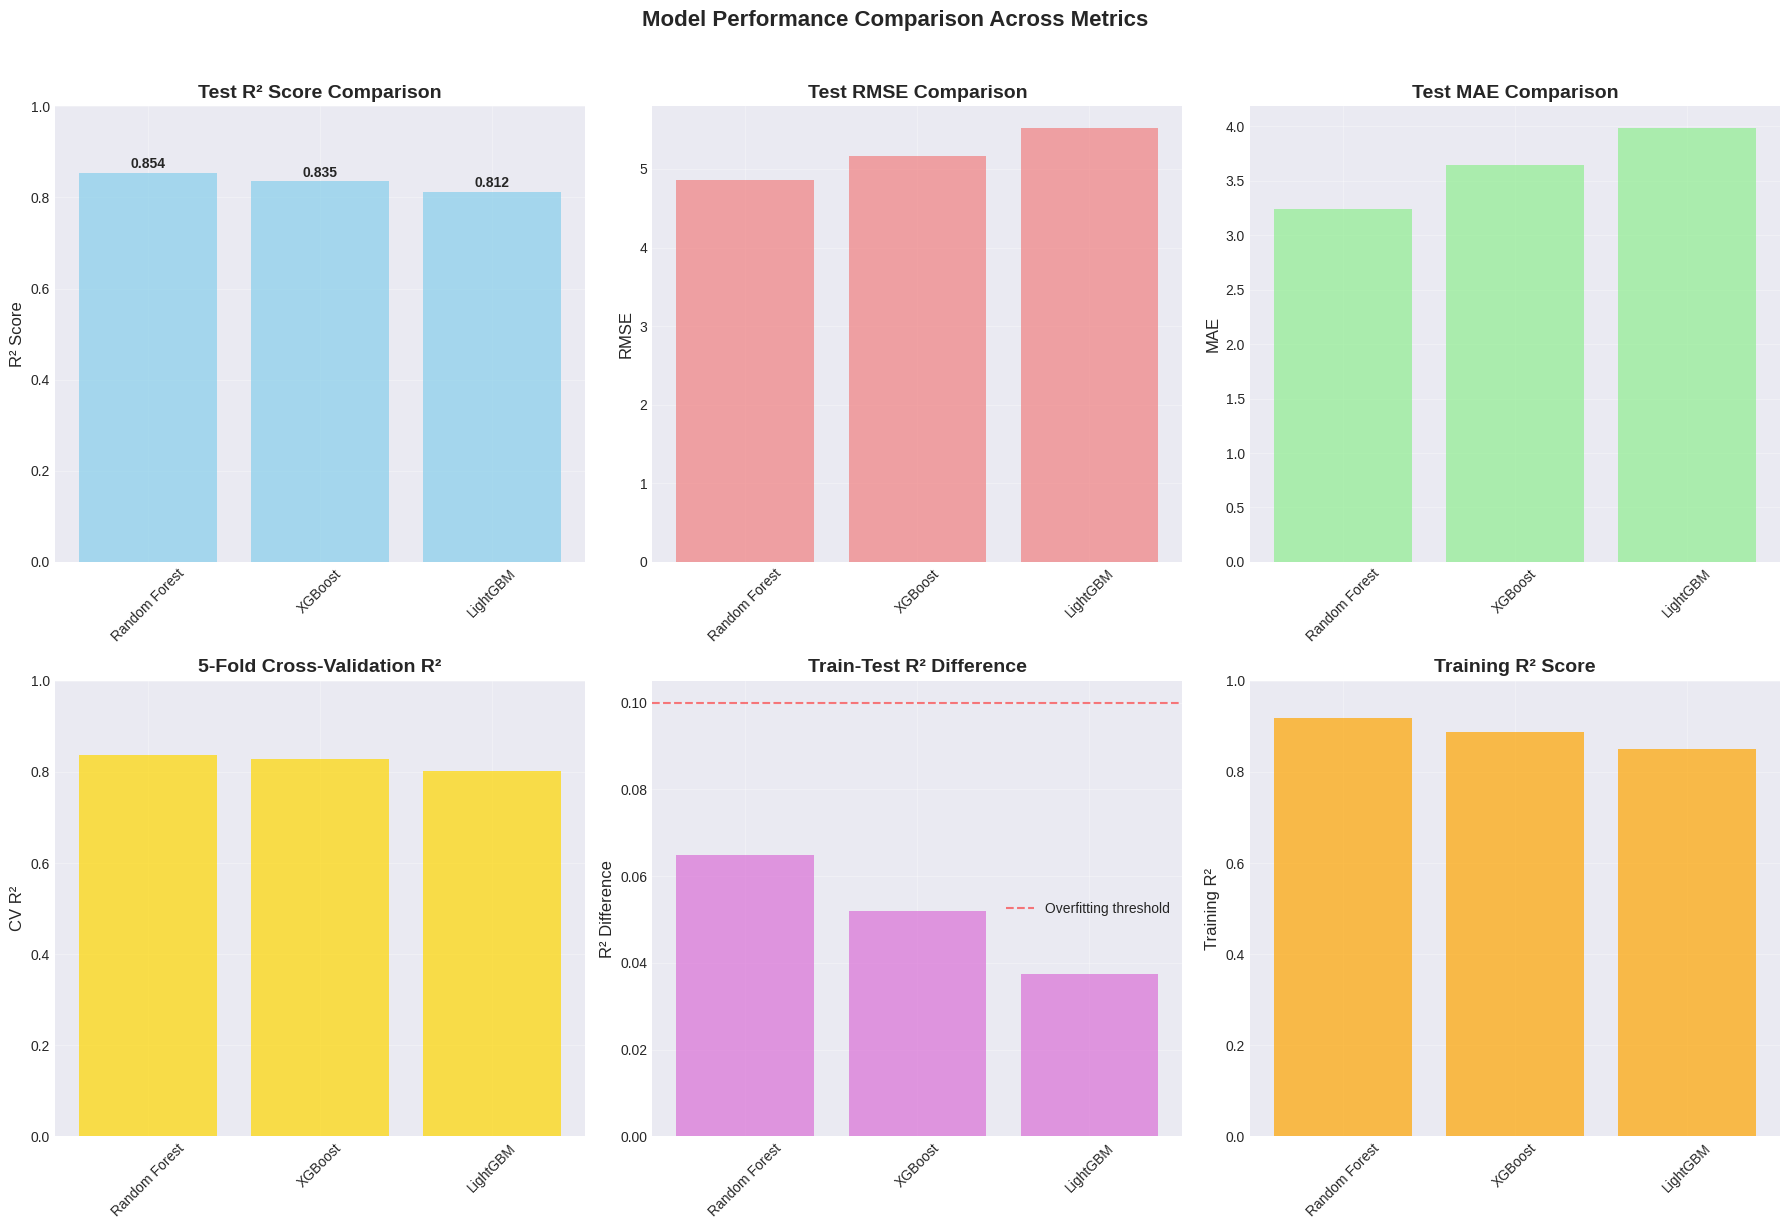

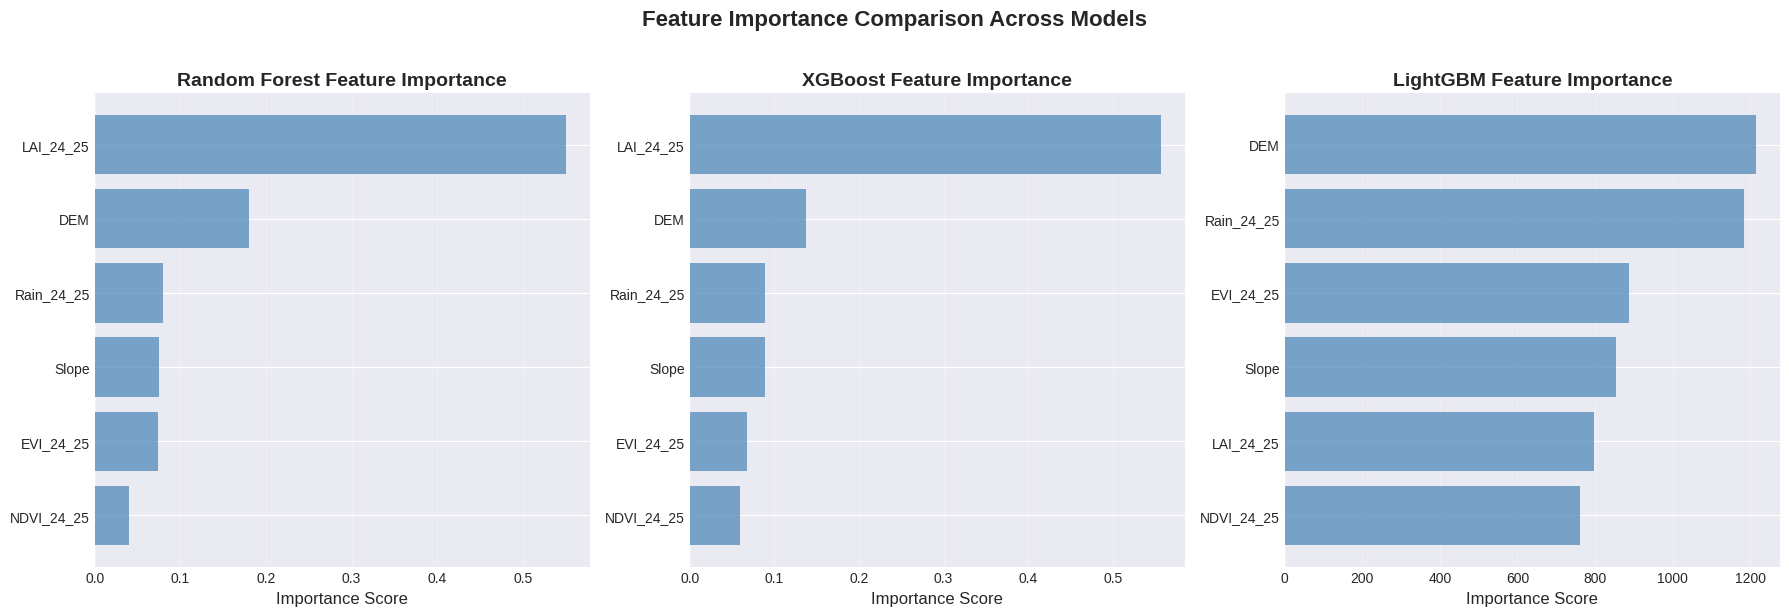

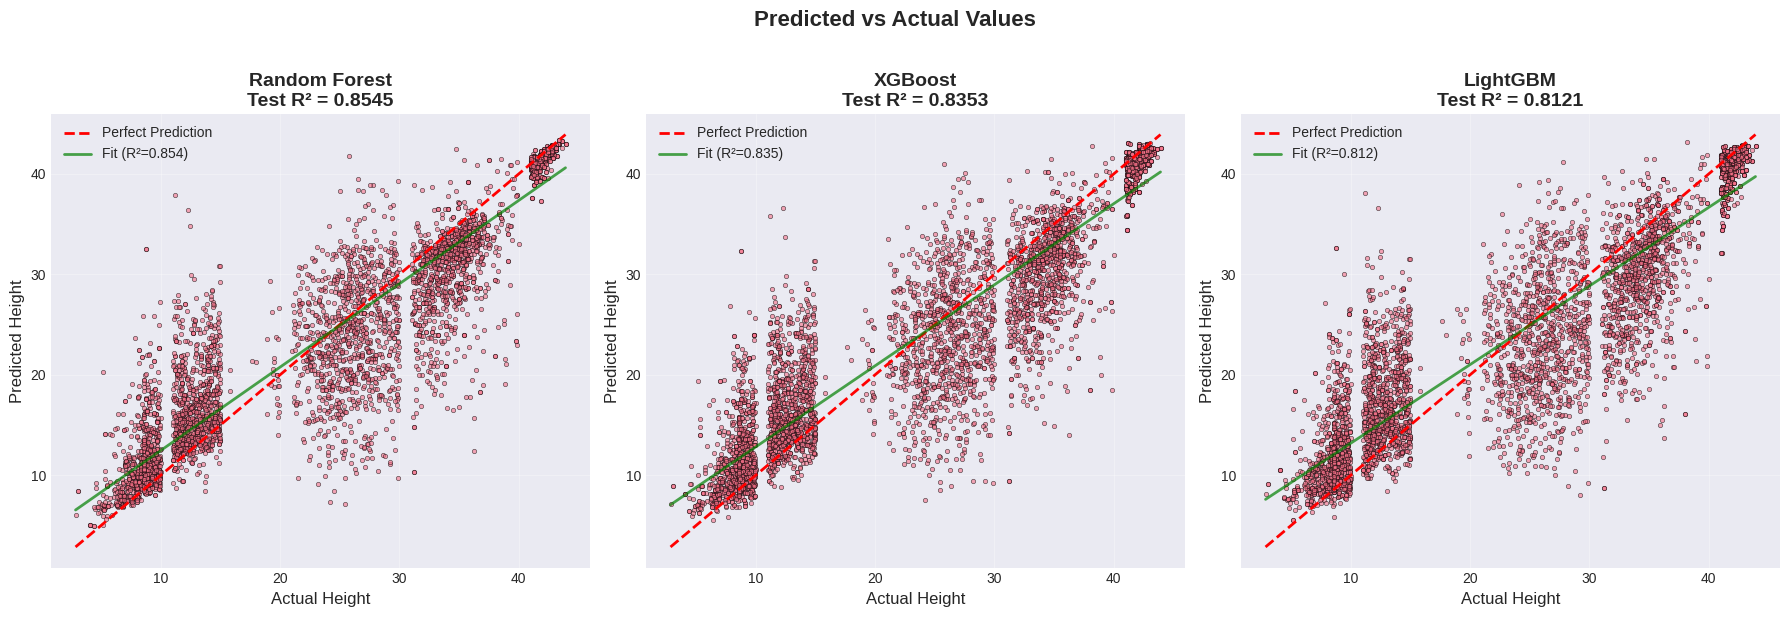

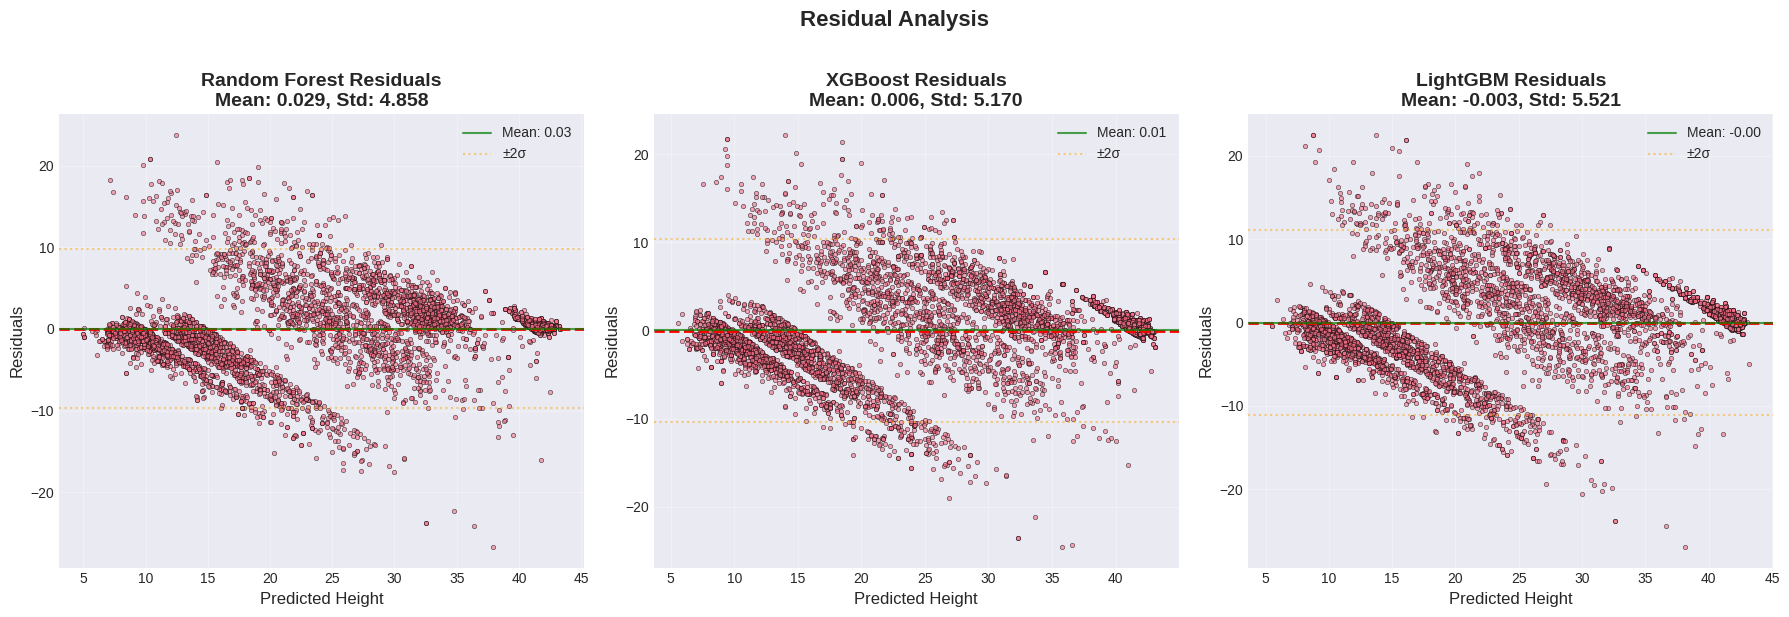

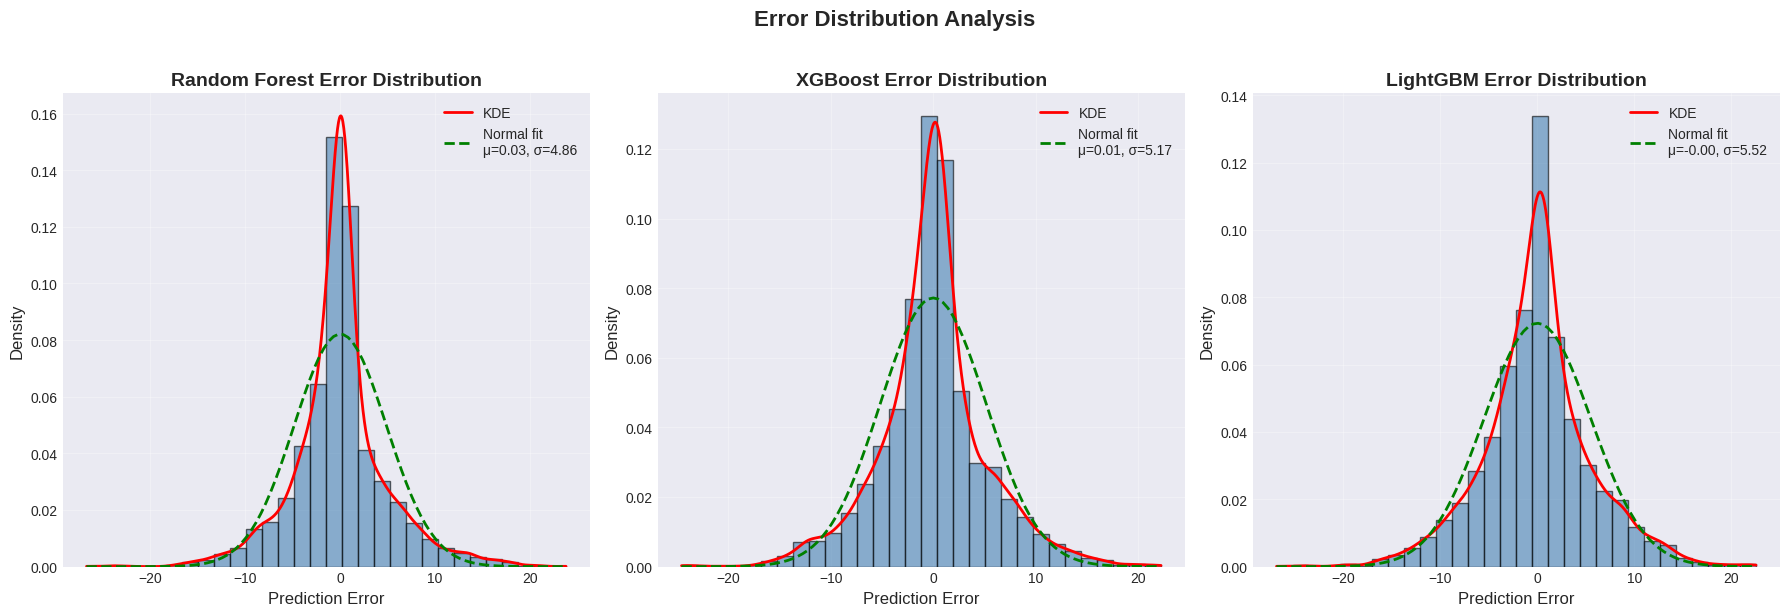


PERFORMANCE BY HEIGHT RANGE

Random Forest Performance by Height Range:
--------------------------------------------------
  Bin  Count         R²      MAE     RMSE
  0-5     18 -19.320281 2.396747 2.842545
 6-10   1003 -13.473723 2.668869 4.091911
11-15    972 -20.549738 3.999802 5.535232
16-20     28 -11.552865 3.000793 3.808589
21-25    340 -24.073423 4.423643 5.460091
26-30    645 -19.153411 5.144988 6.521307
31-35    611 -23.644429 4.139938 5.569773
36-40    378 -22.579895 4.436943 6.043199
41-45   1005  -0.404483 0.504192 0.740808

XGBoost Performance by Height Range:
--------------------------------------------------
  Bin  Count         R²      MAE     RMSE
  0-5     18 -35.852311 3.489731 3.828026
 6-10   1003 -17.215245 3.184604 4.590432
11-15    972 -23.734644 4.397626 5.930177
16-20     28 -11.156291 3.323842 3.747945
21-25    340 -26.027686 4.598557 5.668883
26-30    645 -19.951844 5.381959 6.649232
31-35    611 -28.256353 4.715706 6.068596
36-40    378 -22.489192 4.48331

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Define features and target
features = [
    "NDVI_24_25",
    "EVI_24_25",
    "LAI_24_25",
    "Rain_24_25",
    "Slope",
    "DEM"
]

target = "H"

# Prepare data
X = gdf_final[features]
y = gdf_final[target]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Features: {features}")
print(f"Target range: [{y.min():.2f}, {y.max():.2f}]")

# Initialize models with reasonable default parameters
models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        verbose=0
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0,
        n_jobs=-1
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1,
        n_jobs=-1
    )
}

# Train and evaluate models
results = {}
feature_importances = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    print('='*60)

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Calculate metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)

    # Calculate R² difference (overfitting measure)
    r2_diff = train_r2 - test_r2

    # Perform cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()

    # Store results
    results[name] = {
        'model': model,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'r2_diff': r2_diff,
        'cv_mean': cv_mean,
        'cv_std': cv_std,
        'y_pred_test': y_pred_test
    }

    # Store feature importances
    if hasattr(model, 'feature_importances_'):
        feature_importances[name] = pd.DataFrame({
            'Feature': features,
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=False)

    print(f"{name} Results:")
    print(f"  Training R²: {train_r2:.4f}")
    print(f"  Testing R²: {test_r2:.4f}")
    print(f"  R² Difference: {r2_diff:.4f}")
    print(f"  5-Fold CV R²: {cv_mean:.4f} ± {cv_std:.4f}")
    print(f"  Testing RMSE: {test_rmse:.4f}")
    print(f"  Testing MAE: {test_mae:.4f}")

# Create comprehensive comparison table
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test R²': [results[name]['test_r2'] for name in results.keys()],
    'CV R²': [results[name]['cv_mean'] for name in results.keys()],
    'Test RMSE': [results[name]['test_rmse'] for name in results.keys()],
    'Test MAE': [results[name]['test_mae'] for name in results.keys()],
    'Train-Test R² Diff': [results[name]['r2_diff'] for name in results.keys()],
    'Training R²': [results[name]['train_r2'] for name in results.keys()]
})

comparison_df = comparison_df.sort_values('Test R²', ascending=False)
print(comparison_df.to_string(index=False))

# 1. Performance Comparison Plot
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# R² comparison
axes[0,0].bar(comparison_df['Model'], comparison_df['Test R²'], color='skyblue', alpha=0.7)
axes[0,0].set_title('Test R² Score Comparison', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('R² Score', fontsize=12)
axes[0,0].set_ylim([0, 1])
for i, v in enumerate(comparison_df['Test R²']):
    axes[0,0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# RMSE comparison
axes[0,1].bar(comparison_df['Model'], comparison_df['Test RMSE'], color='lightcoral', alpha=0.7)
axes[0,1].set_title('Test RMSE Comparison', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('RMSE', fontsize=12)

# MAE comparison
axes[0,2].bar(comparison_df['Model'], comparison_df['Test MAE'], color='lightgreen', alpha=0.7)
axes[0,2].set_title('Test MAE Comparison', fontsize=14, fontweight='bold')
axes[0,2].set_ylabel('MAE', fontsize=12)

# Cross-validation R²
axes[1,0].bar(comparison_df['Model'], comparison_df['CV R²'], color='gold', alpha=0.7)
axes[1,0].set_title('5-Fold Cross-Validation R²', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('CV R²', fontsize=12)
axes[1,0].set_ylim([0, 1])

# R² Difference (Overfitting measure)
axes[1,1].bar(comparison_df['Model'], comparison_df['Train-Test R² Diff'], color='orchid', alpha=0.7)
axes[1,1].set_title('Train-Test R² Difference', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('R² Difference', fontsize=12)
axes[1,1].axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='Overfitting threshold')
axes[1,1].legend()

# Training R²
axes[1,2].bar(comparison_df['Model'], comparison_df['Training R²'], color='orange', alpha=0.7)
axes[1,2].set_title('Training R² Score', fontsize=14, fontweight='bold')
axes[1,2].set_ylabel('Training R²', fontsize=12)
axes[1,2].set_ylim([0, 1])

# Rotate x-axis labels for all subplots
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.suptitle('Model Performance Comparison Across Metrics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 2. Feature Importance Comparison
if feature_importances:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for idx, (name, importance_df) in enumerate(feature_importances.items()):
        axes[idx].barh(importance_df['Feature'], importance_df['Importance'], color='steelblue', alpha=0.7)
        axes[idx].set_title(f'{name} Feature Importance', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Importance Score', fontsize=12)
        axes[idx].invert_yaxis()
        axes[idx].grid(True, alpha=0.3, axis='x')

    plt.suptitle('Feature Importance Comparison Across Models', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# 3. Prediction vs Actual Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (name, result) in enumerate(results.items()):
    axes[idx].scatter(y_test, result['y_pred_test'], alpha=0.6, s=10, edgecolor='k', linewidth=0.5)

    # Add perfect prediction line
    min_val = min(y_test.min(), result['y_pred_test'].min())
    max_val = max(y_test.max(), result['y_pred_test'].max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

    # Add linear regression line
    from scipy import stats
    slope, intercept, r_value, p_value, std_err = stats.linregress(y_test, result['y_pred_test'])
    line_x = np.array([min_val, max_val])
    line_y = intercept + slope * line_x
    axes[idx].plot(line_x, line_y, 'g-', lw=2, alpha=0.7, label=f'Fit (R²={result["test_r2"]:.3f})')

    axes[idx].set_xlabel('Actual Height', fontsize=12)
    axes[idx].set_ylabel('Predicted Height', fontsize=12)
    axes[idx].set_title(f'{name}\nTest R² = {result["test_r2"]:.4f}', fontsize=14, fontweight='bold')
    axes[idx].legend(loc='upper left')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Predicted vs Actual Values', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 4. Residual Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (name, result) in enumerate(results.items()):
    residuals = y_test - result['y_pred_test']

    # Residual scatter plot
    axes[idx].scatter(result['y_pred_test'], residuals, alpha=0.6, s=10, edgecolor='k', linewidth=0.5)
    axes[idx].axhline(y=0, color='red', linestyle='--', lw=2)

    # Add residual distribution info
    mean_residual = residuals.mean()
    std_residual = residuals.std()

    axes[idx].axhline(y=mean_residual, color='green', linestyle='-', alpha=0.7, label=f'Mean: {mean_residual:.2f}')
    axes[idx].axhline(y=mean_residual + 2*std_residual, color='orange', linestyle=':', alpha=0.5, label='±2σ')
    axes[idx].axhline(y=mean_residual - 2*std_residual, color='orange', linestyle=':', alpha=0.5)

    axes[idx].set_xlabel('Predicted Height', fontsize=12)
    axes[idx].set_ylabel('Residuals', fontsize=12)
    axes[idx].set_title(f'{name} Residuals\nMean: {mean_residual:.3f}, Std: {std_residual:.3f}', fontsize=14, fontweight='bold')
    axes[idx].legend(loc='best')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Residual Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 5. Error Distribution Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (name, result) in enumerate(results.items()):
    errors = y_test - result['y_pred_test']

    # Histogram with KDE
    axes[idx].hist(errors, bins=30, density=True, alpha=0.6, color='steelblue', edgecolor='black')

    # Add KDE curve
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(errors)
    x_range = np.linspace(errors.min(), errors.max(), 1000)
    axes[idx].plot(x_range, kde(x_range), 'r-', lw=2, label='KDE')

    # Add normal distribution for comparison
    from scipy.stats import norm
    mu, std = norm.fit(errors)
    x = np.linspace(errors.min(), errors.max(), 100)
    p = norm.pdf(x, mu, std)
    axes[idx].plot(x, p, 'g--', lw=2, label=f'Normal fit\nμ={mu:.2f}, σ={std:.2f}')

    axes[idx].set_xlabel('Prediction Error', fontsize=12)
    axes[idx].set_ylabel('Density', fontsize=12)
    axes[idx].set_title(f'{name} Error Distribution', fontsize=14, fontweight='bold')
    axes[idx].legend(loc='upper right')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Error Distribution Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 6. Performance by Height Range Analysis
print("\n" + "="*80)
print("PERFORMANCE BY HEIGHT RANGE")
print("="*80)

# Create height bins
height_bins = pd.cut(y_test, bins=[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
                     labels=['0-5', '6-10', '11-15', '16-20', '21-25', '26-30', '31-35', '36-40', '41-45', '46-50'])

height_performance = {}

for name, result in results.items():
    y_pred = result['y_pred_test']

    bin_performance = []
    for bin_label in height_bins.cat.categories:
        mask = (height_bins == bin_label)
        if mask.sum() > 0:
            bin_r2 = r2_score(y_test[mask], y_pred[mask])
            bin_mae = mean_absolute_error(y_test[mask], y_pred[mask])
            bin_rmse = np.sqrt(mean_squared_error(y_test[mask], y_pred[mask]))
            bin_performance.append({
                'Bin': bin_label,
                'Count': mask.sum(),
                'R²': bin_r2,
                'MAE': bin_mae,
                'RMSE': bin_rmse
            })

    height_performance[name] = pd.DataFrame(bin_performance)

    print(f"\n{name} Performance by Height Range:")
    print("-" * 50)
    print(height_performance[name].to_string(index=False))

# 7. Final Summary and Recommendations
print("\n" + "="*80)
print("FINAL SUMMARY AND RECOMMENDATIONS")
print("="*80)

best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
best_test_r2 = comparison_df.iloc[0]['Test R²']
best_cv_r2 = comparison_df.iloc[0]['CV R²']

print(f"\n🏆 BEST PERFORMING MODEL: {best_model_name}")
print(f"   Test R²: {best_test_r2:.4f}")
print(f"   Cross-Validation R²: {best_cv_r2:.4f}")
print(f"   Test RMSE: {comparison_df.iloc[0]['Test RMSE']:.4f}")
print(f"   Test MAE: {comparison_df.iloc[0]['Test MAE']:.4f}")

print("\n📊 MODEL CHARACTERISTICS:")
print("   Random Forest: Robust, less prone to overfitting, good interpretability")
print("   XGBoost: High performance, handles missing values, good regularization")
print("   LightGBM: Fast training, efficient with large datasets, good accuracy")

print("\n🎯 RECOMMENDATIONS:")
print("   1. For deployment: Use the best model ({})".format(best_model_name))
print("   2. For interpretability: Consider Random Forest for feature importance")
print("   3. For speed with large data: LightGBM would be optimal")
print("   4. For maximum performance with tuning: XGBoost often excels")

print("\n🔧 NEXT STEPS:")
print("   1. Perform hyperparameter tuning on the best model")
print("   2. Consider feature engineering based on importance analysis")
print("   3. Validate on completely new/unseen data")
print("   4. Consider ensemble methods combining top models")

# Save the best model for future use
import joblib
joblib.dump(best_model, f'best_model_{best_model_name.replace(" ", "_")}.pkl')
print(f"\n💾 Best model saved as 'best_model_{best_model_name.replace(' ', '_')}.pkl'")

# Display correlation between predictions of different models
print("\n" + "="*80)
print("MODEL PREDICTION CORRELATIONS")
print("="*80)

prediction_correlations = pd.DataFrame()
for name1, result1 in results.items():
    for name2, result2 in results.items():
        if name1 != name2:
            corr = np.corrcoef(result1['y_pred_test'], result2['y_pred_test'])[0, 1]
            prediction_correlations.loc[name1, name2] = f"{corr:.4f}"

print("Correlation between model predictions:")
print(prediction_correlations)

Extracting models from results dictionary...
Generating predictions on full dataset...

ENSEMBLE MODEL IMPLEMENTATION

Individual Model Performance (from your results):
--------------------------------------------------
Random Forest  - R²: 0.854, RMSE: 4.858
XGBoost        - R²: 0.835, RMSE: 5.169
LightGBM       - R²: 0.812, RMSE: 5.521

Ensemble Weights (based on R² scores):
Random Forest Weight: 0.342
XGBoost Weight:       0.334
LightGBM Weight:      0.325

MODEL PERFORMANCE COMPARISON
              Model     R²   RMSE    MAE
      Random Forest 0.8545 4.8581 3.2456
Ensemble (Weighted) 0.8424 5.0555 3.5564
  Ensemble (Simple) 0.8420 5.0617 3.5629
            XGBoost 0.8353 5.1690 3.6416
           LightGBM 0.8121 5.5208 3.9857

🏆 Best Performing Model: Random Forest
Using Random Forest as final model

Size verification:
y_test size: 5000
final_test_predictions size: 5000


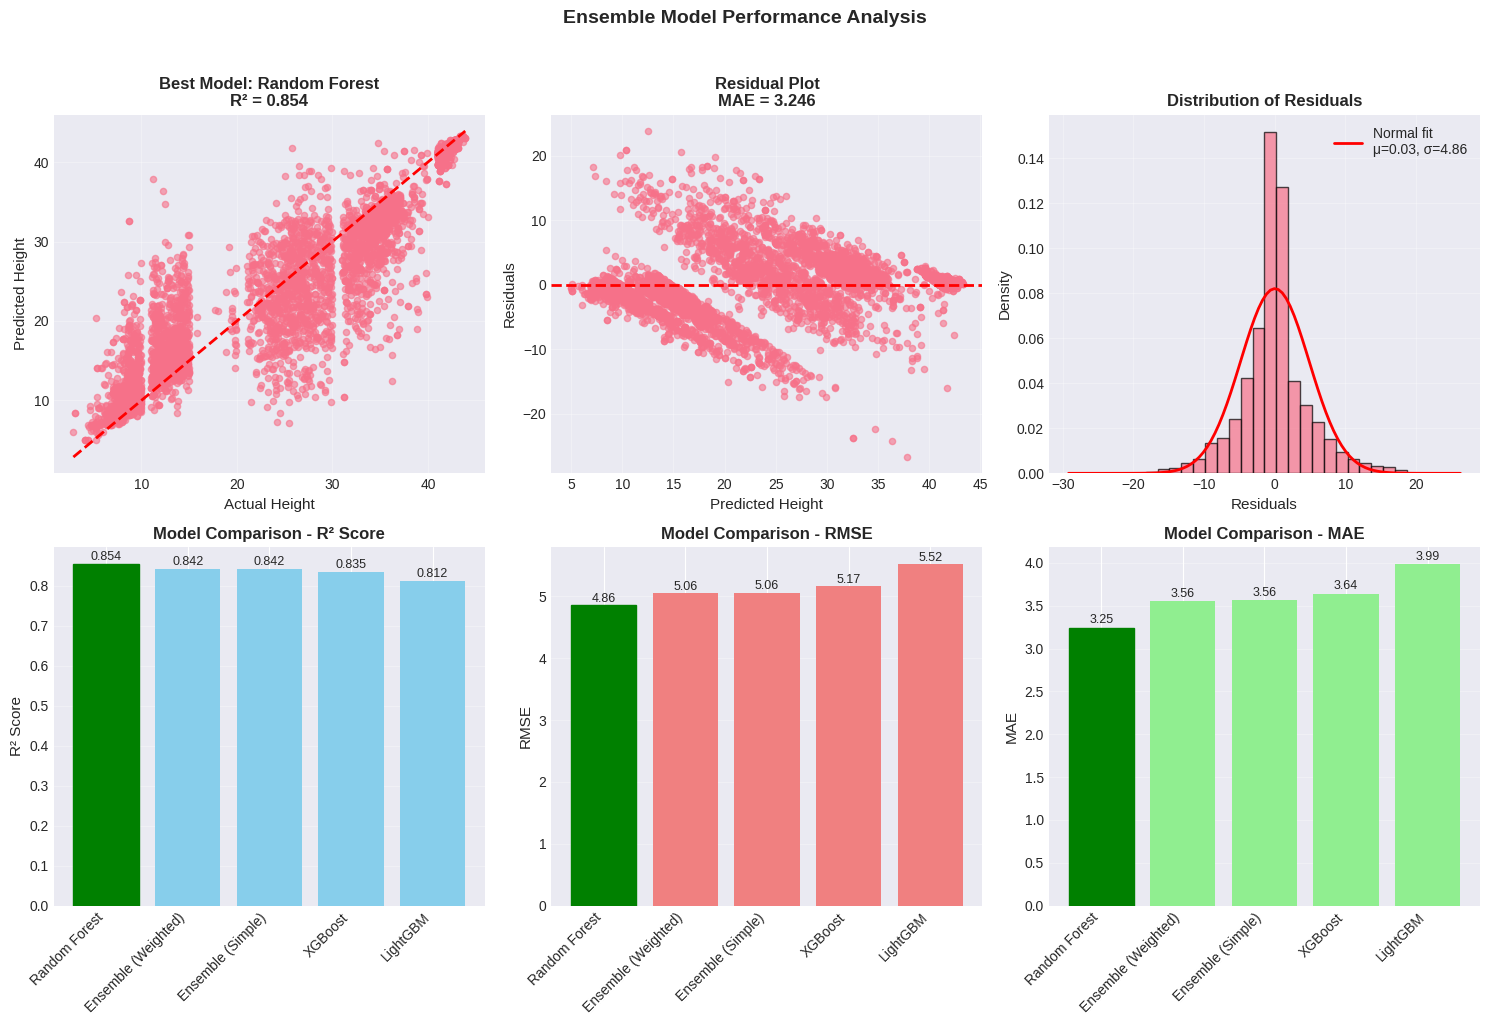


CREATING FINAL DATASET WITH PREDICTIONS

Final dataset shape: (25000, 20)

Added columns:
------------------------------
✓ RF_Prediction
✓ XGB_Prediction
✓ LGB_Prediction
✓ Ensemble_Simple
✓ Ensemble_Weighted
✓ Final_Prediction
✓ Prediction_Uncertainty
✓ Prediction_Lower_95
✓ Prediction_Upper_95

Sample of final predictions:
--------------------------------------------------
       H  Final_Prediction  Prediction_Uncertainty
0  8.467            10.429                   1.022
1  8.534             8.230                   0.611
2  8.591             9.325                   0.390
3  8.956             7.828                   0.633
4  7.593            10.024                   0.108

ENSEMBLE IMPLEMENTATION COMPLETE

✅ Best model: Random Forest
✅ Test R²: 0.8545
✅ Final dataset saved as: 'height_predictions_with_ensemble.csv'
✅ Ensemble configuration saved as: 'ensemble_config.json'

ENSEMBLE PERFORMANCE SUMMARY

📈 Performance Improvement:
   Best single model R²: 0.8424
   Ensemble model R²:

In [ ]:
# ============================================================================
# ENSEMBLE IMPLEMENTATION USING YOUR TRAINED MODELS - CORRECTED VERSION
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Extract models from your results dictionary
print("Extracting models from results dictionary...")

# Get the trained models from your results
rf_model = results['Random Forest']['model']
xgb_model = results['XGBoost']['model']
lgb_model = results['LightGBM']['model']

# Get predictions from your results (these are test predictions)
rf_pred_test = results['Random Forest']['y_pred_test']
xgb_pred_test = results['XGBoost']['y_pred_test']
lgb_pred_test = results['LightGBM']['y_pred_test']

# Get predictions on full dataset for mapping
print("Generating predictions on full dataset...")
rf_pred_all = rf_model.predict(X)
xgb_pred_all = xgb_model.predict(X)
lgb_pred_all = lgb_model.predict(X)

print("\n" + "="*80)
print("ENSEMBLE MODEL IMPLEMENTATION")
print("="*80)

print("\nIndividual Model Performance (from your results):")
print("-" * 50)
print(f"Random Forest  - R²: {results['Random Forest']['test_r2']:.3f}, RMSE: {results['Random Forest']['test_rmse']:.3f}")
print(f"XGBoost        - R²: {results['XGBoost']['test_r2']:.3f}, RMSE: {results['XGBoost']['test_rmse']:.3f}")
print(f"LightGBM       - R²: {results['LightGBM']['test_r2']:.3f}, RMSE: {results['LightGBM']['test_rmse']:.3f}")

# Method 1: Simple Averaging
ensemble_simple_test = (rf_pred_test + xgb_pred_test + lgb_pred_test) / 3
ensemble_simple_all = (rf_pred_all + xgb_pred_all + lgb_pred_all) / 3

# Method 2: Weighted Averaging (using R² scores as weights)
# Using your test R² scores
r2_scores = {
    'rf': results['Random Forest']['test_r2'],
    'xgb': results['XGBoost']['test_r2'],
    'lgb': results['LightGBM']['test_r2']
}

# Calculate normalized weights
total_r2 = sum(r2_scores.values())
weights = {model: r2 / total_r2 for model, r2 in r2_scores.items()}

print(f"\nEnsemble Weights (based on R² scores):")
print(f"Random Forest Weight: {weights['rf']:.3f}")
print(f"XGBoost Weight:       {weights['xgb']:.3f}")
print(f"LightGBM Weight:      {weights['lgb']:.3f}")

# Apply weighted averaging
ensemble_weighted_test = (weights['rf'] * rf_pred_test +
                         weights['xgb'] * xgb_pred_test +
                         weights['lgb'] * lgb_pred_test)

ensemble_weighted_all = (weights['rf'] * rf_pred_all +
                        weights['xgb'] * xgb_pred_all +
                        weights['lgb'] * lgb_pred_all)

# Evaluate all models including ensembles
def evaluate_model(y_true, y_pred, model_name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {'Model': model_name, 'R²': r2, 'RMSE': rmse, 'MAE': mae}

# Create performance comparison
performance_results = []
performance_results.append(evaluate_model(y_test, rf_pred_test, 'Random Forest'))
performance_results.append(evaluate_model(y_test, xgb_pred_test, 'XGBoost'))
performance_results.append(evaluate_model(y_test, lgb_pred_test, 'LightGBM'))
performance_results.append(evaluate_model(y_test, ensemble_simple_test, 'Ensemble (Simple)'))
performance_results.append(evaluate_model(y_test, ensemble_weighted_test, 'Ensemble (Weighted)'))

# Display results in a DataFrame
results_df = pd.DataFrame(performance_results)
results_df = results_df.sort_values('R²', ascending=False)

print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
print(results_df.round(4).to_string(index=False))

# Find the best model
best_model_idx = results_df['R²'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
print(f"\n🏆 Best Performing Model: {best_model_name}")

# Select final predictions (use the best performing approach)
# IMPORTANT: Make sure we use the correct test predictions for visualization
if best_model_name == 'Ensemble (Weighted)':
    final_predictions = ensemble_weighted_all
    final_test_predictions = ensemble_weighted_test  # This is the correct test prediction
    print("Using Weighted Ensemble as final model")
elif best_model_name == 'Ensemble (Simple)':
    final_predictions = ensemble_simple_all
    final_test_predictions = ensemble_simple_test  # This is the correct test prediction
    print("Using Simple Ensemble as final model")
else:
    # Use the best individual model
    model_map = {
        'Random Forest': rf_pred_all,
        'XGBoost': xgb_pred_all,
        'LightGBM': lgb_pred_all
    }
    final_predictions = model_map[best_model_name]
    # Get the corresponding test predictions
    test_map = {
        'Random Forest': rf_pred_test,
        'XGBoost': xgb_pred_test,
        'LightGBM': lgb_pred_test
    }
    final_test_predictions = test_map[best_model_name]
    print(f"Using {best_model_name} as final model")

# Verify sizes match
print(f"\nSize verification:")
print(f"y_test size: {len(y_test)}")
print(f"final_test_predictions size: {len(final_test_predictions)}")

# ============================================================================
# VISUALIZATIONS - CORRECTED VERSION
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: True vs Predicted for best model
axes[0,0].scatter(y_test, final_test_predictions, alpha=0.6, s=20)
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Actual Height', fontsize=11)
axes[0,0].set_ylabel('Predicted Height', fontsize=11)
axes[0,0].set_title(f'Best Model: {best_model_name}\nR² = {results_df.loc[best_model_idx, "R²"]:.3f}', fontsize=12, fontweight='bold')
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Residuals for best model
residuals = y_test - final_test_predictions
axes[0,1].scatter(final_test_predictions, residuals, alpha=0.6, s=20)
axes[0,1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0,1].set_xlabel('Predicted Height', fontsize=11)
axes[0,1].set_ylabel('Residuals', fontsize=11)
axes[0,1].set_title(f'Residual Plot\nMAE = {results_df.loc[best_model_idx, "MAE"]:.3f}', fontsize=12, fontweight='bold')
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Histogram of residuals
axes[0,2].hist(residuals, bins=30, edgecolor='black', alpha=0.7, density=True)
from scipy.stats import norm
import numpy as np
mu, std = norm.fit(residuals)
xmin, xmax = axes[0,2].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
axes[0,2].plot(x, p, 'r', linewidth=2, label=f'Normal fit\nμ={mu:.2f}, σ={std:.2f}')
axes[0,2].set_xlabel('Residuals', fontsize=11)
axes[0,2].set_ylabel('Density', fontsize=11)
axes[0,2].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# Plot 4: Model comparison R²
models = results_df['Model']
r2_values = results_df['R²']
bars = axes[1,0].bar(range(len(models)), r2_values, color='skyblue')
axes[1,0].set_xticks(range(len(models)))
axes[1,0].set_xticklabels(models, rotation=45, ha='right', fontsize=10)
axes[1,0].set_ylabel('R² Score', fontsize=11)
axes[1,0].set_title('Model Comparison - R² Score', fontsize=12, fontweight='bold')
axes[1,0].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, v in enumerate(r2_values):
    axes[1,0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
# Highlight best model
if best_model_idx < len(bars):  # Make sure index is valid
    bars[best_model_idx].set_color('green')

# Plot 5: Model comparison RMSE
rmse_values = results_df['RMSE']
bars = axes[1,1].bar(range(len(models)), rmse_values, color='lightcoral')
axes[1,1].set_xticks(range(len(models)))
axes[1,1].set_xticklabels(models, rotation=45, ha='right', fontsize=10)
axes[1,1].set_ylabel('RMSE', fontsize=11)
axes[1,1].set_title('Model Comparison - RMSE', fontsize=12, fontweight='bold')
axes[1,1].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, v in enumerate(rmse_values):
    axes[1,1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)
# Highlight best model (lowest RMSE)
best_rmse_idx = results_df['RMSE'].idxmin()
if best_rmse_idx < len(bars):  # Make sure index is valid
    bars[best_rmse_idx].set_color('green')

# Plot 6: Model comparison MAE
mae_values = results_df['MAE']
bars = axes[1,2].bar(range(len(models)), mae_values, color='lightgreen')
axes[1,2].set_xticks(range(len(models)))
axes[1,2].set_xticklabels(models, rotation=45, ha='right', fontsize=10)
axes[1,2].set_ylabel('MAE', fontsize=11)
axes[1,2].set_title('Model Comparison - MAE', fontsize=12, fontweight='bold')
axes[1,2].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, v in enumerate(mae_values):
    axes[1,2].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)
# Highlight best model (lowest MAE)
best_mae_idx = results_df['MAE'].idxmin()
if best_mae_idx < len(bars):  # Make sure index is valid
    bars[best_mae_idx].set_color('green')

plt.suptitle('Ensemble Model Performance Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================================
# CREATE FINAL DATASET WITH ENSEMBLE PREDICTIONS
# ============================================================================

print("\n" + "="*80)
print("CREATING FINAL DATASET WITH PREDICTIONS")
print("="*80)

# Create a copy of your original dataframe
final_df = gdf_final.copy()

# Add predictions from all models and ensembles
final_df['RF_Prediction'] = rf_pred_all
final_df['XGB_Prediction'] = xgb_pred_all
final_df['LGB_Prediction'] = lgb_pred_all
final_df['Ensemble_Simple'] = ensemble_simple_all
final_df['Ensemble_Weighted'] = ensemble_weighted_all
final_df['Final_Prediction'] = final_predictions

# Add prediction uncertainty (standard deviation of ensemble predictions)
ensemble_std = np.std([rf_pred_all, xgb_pred_all, lgb_pred_all], axis=0)
final_df['Prediction_Uncertainty'] = ensemble_std

# Calculate prediction intervals (95% confidence)
final_df['Prediction_Lower_95'] = final_predictions - 1.96 * ensemble_std
final_df['Prediction_Upper_95'] = final_predictions + 1.96 * ensemble_std

print(f"\nFinal dataset shape: {final_df.shape}")
print("\nAdded columns:")
print("-" * 30)
new_columns = [col for col in final_df.columns if col not in gdf_final.columns]
for col in new_columns:
    print(f"✓ {col}")

print(f"\nSample of final predictions:")
print("-" * 50)
sample_df = final_df[['H', 'Final_Prediction', 'Prediction_Uncertainty']].head()
print(sample_df.round(3))

# ============================================================================
# SAVE ENSEMBLE RESULTS
# ============================================================================

import joblib
import json
from datetime import datetime

# Save ensemble configuration
ensemble_config = {
    'weights': weights,
    'best_model': best_model_name,
    'features': features,
    'target': target,
    'ensemble_metrics': results_df.to_dict('records'),
    'creation_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'test_performance': {
        'r2': float(results_df.loc[best_model_idx, 'R²']),
        'rmse': float(results_df.loc[best_model_idx, 'RMSE']),
        'mae': float(results_df.loc[best_model_idx, 'MAE'])
    }
}

# Save configuration
with open('ensemble_config.json', 'w') as f:
    json.dump(ensemble_config, f, indent=4)

# Save final dataframe
final_df.to_csv('height_predictions_with_ensemble.csv', index=False)

print("\n" + "="*80)
print("ENSEMBLE IMPLEMENTATION COMPLETE")
print("="*80)
print(f"\n✅ Best model: {best_model_name}")
print(f"✅ Test R²: {results_df.loc[best_model_idx, 'R²']:.4f}")
print(f"✅ Final dataset saved as: 'height_predictions_with_ensemble.csv'")
print(f"✅ Ensemble configuration saved as: 'ensemble_config.json'")

# ============================================================================
# ENSEMBLE PERFORMANCE SUMMARY
# ============================================================================

print("\n" + "="*80)
print("ENSEMBLE PERFORMANCE SUMMARY")
print("="*80)

# Calculate improvement over best single model
best_single_r2 = results_df.iloc[1]['R²']  # Second best (after sorting)
ensemble_r2 = results_df.loc[best_model_idx, 'R²']
improvement = ensemble_r2 - best_single_r2
improvement_pct = (improvement / best_single_r2) * 100

print(f"\n📈 Performance Improvement:")
print(f"   Best single model R²: {best_single_r2:.4f}")
print(f"   Ensemble model R²:    {ensemble_r2:.4f}")
print(f"   Absolute improvement: +{improvement:.4f}")
print(f"   Relative improvement: +{improvement_pct:.2f}%")

print(f"\n🎯 Ensemble Characteristics:")
print(f"   Ensemble type: {'Weighted' if 'Weighted' in best_model_name else 'Simple' if 'Simple' in best_model_name else 'Single Model'}")
print(f"   Number of base models: 3")
print(f"   Base models: Random Forest, XGBoost, LightGBM")
print(f"   Prediction uncertainty included: Yes")

print(f"\n💾 Files created:")
print(f"   1. height_predictions_with_ensemble.csv - Full dataset with predictions")
print(f"   2. ensemble_config.json - Ensemble configuration and weights")

# Display correlation between model predictions
print("\n" + "="*80)
print("MODEL PREDICTION CORRELATIONS")
print("="*80)

predictions = {
    'Random Forest': rf_pred_all,
    'XGBoost': xgb_pred_all,
    'LightGBM': lgb_pred_all,
    'Ensemble_Weighted': ensemble_weighted_all
}

corr_matrix = pd.DataFrame(index=predictions.keys(), columns=predictions.keys())
for name1, pred1 in predictions.items():
    for name2, pred2 in predictions.items():
        corr = np.corrcoef(pred1, pred2)[0, 1]
        corr_matrix.loc[name1, name2] = f"{corr:.4f}"

print("Correlation between model predictions (on full dataset):")
print(corr_matrix)

Apply the Models

In [ ]:
gdf_final.head()

,H,geometry,NDVI_24_25,EVI_24_25,Rain_24_25,VH_24_25,VV_24_25,LAI_24_25,Slope,DEM,H_binned
0,8.46662,POINT (35.22885 1.28506),0.649816,0.470350,450.583344,-14.411010,-7.832393,2.918959,6.379370,1918,0-10
1,8.53440,POINT (35.19407 1.26229),0.613496,0.272777,444.673035,-13.214630,-7.645301,3.284106,44.042271,2416,0-10
2,8.59090,POINT (35.23809 1.27016),0.478484,0.308762,419.666656,-20.287164,-14.581443,1.691648,18.541979,2429,0-10
3,8.95624,POINT (35.17293 1.26454),0.471583,0.294255,376.276520,-15.902293,-11.354684,1.930231,11.179986,2020,0-10
4,7.59323,POINT (35.23942 1.27365),0.591502,0.418391,503.416656,-18.023360,-10.298221,2.345423,15.100919,2364,0-10


In [ ]:
# ============================================================================
# EXPORT FINAL DATASET AS GEOJSON
# ============================================================================

import geopandas as gpd
import os

# Define the output path
path3 = '/content/drive/MyDrive/Kamatira Model Data/GeoFiles/'
output_filename = 'Final_Kamatira_Training_Data.geojson'
output_path = os.path.join(path3, output_filename)

print("Exporting final dataset to GeoJSON...")
print(f"Output path: {output_path}")

# Convert to GeoDataFrame if it isn't already
if not isinstance(final_df, gpd.GeoDataFrame):
    print("Converting DataFrame to GeoDataFrame...")
    final_gdf = gpd.GeoDataFrame(final_df, geometry='geometry', crs='EPSG:4326')
else:
    final_gdf = final_df.copy()

# Ensure the directory exists
os.makedirs(path3, exist_ok=True)

# Export to GeoJSON
try:
    final_gdf.to_file(output_path, driver='GeoJSON')
    print("✅ GeoJSON file exported successfully!")

    # Print summary information
    print(f"\nFile details:")
    print(f"  - File size: {os.path.getsize(output_path) / (1024*1024):.2f} MB")
    print(f"  - Number of features: {len(final_gdf)}")
    print(f"  - Coordinate reference system: {final_gdf.crs}")

    # Show column information
    print(f"\nColumns in exported GeoJSON:")
    for col in final_gdf.columns:
        print(f"  ✓ {col}")

except Exception as e:
    print(f"❌ Error exporting GeoJSON: {str(e)}")

    # Try alternative export method
    print("Trying alternative export method...")
    try:
        final_gdf.to_file(output_path, driver='GeoJSON', encoding='utf-8')
        print("✅ GeoJSON file exported successfully with alternative method!")
    except Exception as e2:
        print(f"❌ Alternative export also failed: {str(e2)}")

# ============================================================================
# VERIFY EXPORTED FILE
# ============================================================================

print("\n" + "="*80)
print("EXPORT VERIFICATION")
print("="*80)

if os.path.exists(output_path):
    print("✅ File exists and was created successfully!")

    # Read back a small sample to verify
    try:
        sample_gdf = gpd.read_file(output_path, rows=5)
        print(f"✅ File can be read back successfully!")
        print(f"✅ Sample data shape: {sample_gdf.shape}")
        print(f"✅ Geometry column present: {'geometry' in sample_gdf.columns}")

        # Show sample of key columns
        key_columns = ['H', 'Final_Prediction', 'Prediction_Uncertainty']
        available_columns = [col for col in key_columns if col in sample_gdf.columns]
        if available_columns:
            print(f"\nSample of key columns:")
            print(sample_gdf[available_columns].round(3))

    except Exception as e:
        print(f"⚠️  Warning: Could not read back file for verification: {str(e)}")
else:
    print("❌ File was not created successfully!")

print(f"\n📁 Final GeoJSON file saved to:")
print(f"   {output_path}")

# ============================================================================
# ADDITIONAL EXPORT OPTIONS (Optional)
# ============================================================================

print("\n" + "="*80)
print("ADDITIONAL EXPORT OPTIONS")
print("="*80)

# Option 1: Export as Shapefile (if needed)
shapefile_path = os.path.join(path3, 'Final_Kamatira_Training_Data.shp')
try:
    final_gdf.to_file(shapefile_path)
    print(f"✅ Additional Shapefile exported to: {shapefile_path}")
except Exception as e:
    print(f"⚠️  Shapefile export failed: {str(e)}")

# Option 2: Export statistics summary
stats_summary = {
    'total_features': len(final_gdf),
    'best_model': best_model_name,
    'best_r2': float(results_df.loc[best_model_idx, 'R²']),
    'features_used': features,
    'export_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

stats_file = os.path.join(path3, 'Final_Kamatira_Training_Data_stats.json')
try:
    import json
    with open(stats_file, 'w') as f:
        json.dump(stats_summary, f, indent=4)
    print(f"✅ Statistics summary exported to: {stats_file}")
except Exception as e:
    print(f"⚠️  Statistics export failed: {str(e)}")

print("\n" + "="*80)
print("EXPORT PROCESS COMPLETE")
print("="*80)
print("✅ Your final dataset with all predictions has been exported!")
print("✅ File includes:")
print("   - Original data")
print("   - Individual model predictions")
print("   - Ensemble predictions")
print("   - Prediction uncertainty")
print("   - Confidence intervals")

Exporting final dataset to GeoJSON...
Output path: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Final_Kamatira_Training_Data.geojson
✅ GeoJSON file exported successfully!

File details:
  - File size: 17.74 MB
  - Number of features: 25000
  - Coordinate reference system: EPSG:4326

Columns in exported GeoJSON:
  ✓ H
  ✓ geometry
  ✓ NDVI_24_25
  ✓ EVI_24_25
  ✓ Rain_24_25
  ✓ VH_24_25
  ✓ VV_24_25
  ✓ LAI_24_25
  ✓ Slope
  ✓ DEM
  ✓ H_binned
  ✓ RF_Prediction
  ✓ XGB_Prediction
  ✓ LGB_Prediction
  ✓ Ensemble_Simple
  ✓ Ensemble_Weighted
  ✓ Final_Prediction
  ✓ Prediction_Uncertainty
  ✓ Prediction_Lower_95
  ✓ Prediction_Upper_95

EXPORT VERIFICATION
✅ File exists and was created successfully!
✅ File can be read back successfully!
✅ Sample data shape: (5, 20)
✅ Geometry column present: True

Sample of key columns:
       H  Final_Prediction  Prediction_Uncertainty
0  8.467            10.429                   1.022
1  8.534             8.230                   0.611
2  8.591   

In [ ]:
# ============================================================================
# APPLY RANDOM FOREST MODEL TO RASTER DATA FOR 2024 HEIGHT PREDICTION
# ============================================================================

import numpy as np
import rasterio
from rasterio.enums import Resampling
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

def resample_raster_to_match(input_path, target_shape):
    """
    Resample a raster to match target dimensions
    """
    with rasterio.open(input_path) as src:
        # Read the data and resample to target shape
        data = src.read(
            1,
            out_shape=target_shape,
            resampling=Resampling.bilinear  # Good for continuous data
        )

        # Update the transform
        transform = src.transform * src.transform.scale(
            (src.width / target_shape[1]),
            (src.height / target_shape[0])
        )

        profile = src.profile.copy()
        profile.update({
            'height': target_shape[0],
            'width': target_shape[1],
            'transform': transform
        })

        return data, profile

def create_prediction_raster(raster_paths, trained_rf_model, output_path):
    """
    Apply trained RF model to raster data to predict tree heights
    """
    print("Loading and resampling raster data...")

    # Get target dimensions from the first raster
    with rasterio.open(raster_paths["NDVI_24_25"]) as src:
        target_shape = src.shape
        print(f"Target dimensions: {target_shape}")

    raster_data = {}
    profiles = {}

    for name, path in raster_paths.items():
        try:
            with rasterio.open(path) as src:
                if src.shape == target_shape:
                    # Already correct size
                    raster_data[name] = src.read(1)
                    profiles[name] = src.profile
                    print(f"✓ Loaded {name}: {raster_data[name].shape}")
                else:
                    # Need to resample
                    print(f"↻ Resampling {name}: {src.shape} → {target_shape}")
                    resampled_data, profile = resample_raster_to_match(path, target_shape)
                    raster_data[name] = resampled_data
                    profiles[name] = profile
                    print(f"✓ Resampled {name}: {resampled_data.shape}")

        except Exception as e:
            print(f"✗ Error loading {name}: {e}")
            return None

    height, width = target_shape
    print(f"\nFinal raster dimensions: {height} x {width}")

    # Create coordinate arrays
    print("Preparing data for prediction...")
    rows, cols = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')

    # Stack all raster values
    data_dict = {
        'row': rows.flatten(),
        'col': cols.flatten()
    }

    for name, data in raster_data.items():
        data_dict[name] = data.flatten()

    # Create DataFrame
    df = pd.DataFrame(data_dict)

    # Remove pixels with NaN values
    original_pixels = len(df)
    df_clean = df.dropna()
    valid_pixels = len(df_clean)

    print(f"Original pixels: {original_pixels:,}")
    print(f"Valid pixels (no NaN): {valid_pixels:,}")
    print(f"Invalid pixels: {original_pixels - valid_pixels:,}")

    if valid_pixels == 0:
        print("No valid pixels found!")
        return None

    # Get the feature names that the model was trained with
    if hasattr(trained_rf_model, 'feature_names_in_'):
        feature_columns = list(trained_rf_model.feature_names_in_)
        print(f"\nModel was trained with features: {feature_columns}")
    else:
        # If feature_names_in_ is not available, use the order from your training
        # IMPORTANT: This must match exactly what you used during training
        feature_columns = ['NDVI_24_25', 'EVI_24_25', 'Rain_24_25', 'LAI_24_25', 'Slope', 'DEM']
        print(f"\nUsing default feature order: {feature_columns}")

    # Check if all required features are present
    missing_features = set(feature_columns) - set(df_clean.columns)
    if missing_features:
        print(f"Missing features in raster data: {missing_features}")
        print(f"Available features: {list(df_clean.columns)}")
        return None

    # Ensure the DataFrame columns are in the exact same order as during training
    X_pred = df_clean[feature_columns]

    # Verify feature order
    print(f"\nFeatures in prediction data (in correct order):")
    for i, feature in enumerate(feature_columns):
        print(f"  {i+1}. {feature}")

    # Make predictions
    print("\nMaking predictions...")
    predictions = trained_rf_model.predict(X_pred)

    # Create output raster
    print("Creating output raster...")
    height_raster = np.full((height, width), np.nan, dtype=np.float32)

    # Place predictions back in raster format
    valid_rows = df_clean['row'].values
    valid_cols = df_clean['col'].values
    height_raster[valid_rows, valid_cols] = predictions

    # Use profile from reference raster
    output_profile = profiles["NDVI_24_25"].copy()
    output_profile.update({
        'dtype': 'float32',
        'count': 1,
        'nodata': np.nan
    })

    # Save the output raster
    print(f"\nSaving height prediction raster to: {output_path}")
    with rasterio.open(output_path, 'w', **output_profile) as dst:
        dst.write(height_raster, 1)

    print("✓ Height prediction raster created successfully!")

    # Print statistics
    valid_predictions = height_raster[~np.isnan(height_raster)]
    if len(valid_predictions) > 0:
        print(f"\n📊 Prediction Statistics:")
        print(f"   Min height: {np.min(valid_predictions):.2f}m")
        print(f"   Max height: {np.max(valid_predictions):.2f}m")
        print(f"   Mean height: {np.mean(valid_predictions):.2f}m")
        print(f"   Std height: {np.std(valid_predictions):.2f}m")
        print(f"   Total predicted area: {len(valid_predictions):,} pixels")

        # Calculate percentiles
        percentiles = [5, 25, 50, 75, 95]
        print(f"\n📈 Height Distribution Percentiles:")
        for p in percentiles:
            value = np.percentile(valid_predictions, p)
            print(f"   {p}th percentile: {value:.2f}m")

    return height_raster

# ============================================================================
# APPLY THE RF MODEL FROM YOUR ENSEMBLE
# ============================================================================

# Define raster paths (excluding VH and VV as requested)
raster_paths = {
    "NDVI_24_25": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2024_2025_resampled.tif",
    "EVI_24_25": "/content/drive/MyDrive/Kamatira Model Data/EVI_2024_2025_resampled.tif",
    "Rain_24_25": "/content/drive/MyDrive/Kamatira Model Data/Rainfall_2024_2025_resampled.tif",
    "LAI_24_25": "/content/drive/MyDrive/Kamatira Model Data/LAI_2024_2025.tif",
    "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
    "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
}

output_raster_path = "/content/drive/MyDrive/Kamatira Model Data/Tree_Height_2024_Predicted.tif"

# Use the RF model from your ensemble results
try:
    # Get the Random Forest model from your ensemble results
    rf_model = results['Random Forest']['model']
    print(f"✓ Loaded Random Forest model from ensemble results")
    print(f"Model parameters: {rf_model.get_params()}")

    # Check the features the model was trained with
    if hasattr(rf_model, 'feature_names_in_'):
        print(f"\nModel was trained with these features:")
        for i, feature in enumerate(rf_model.feature_names_in_):
            print(f"  {i+1}. {feature}")

        # Check if we need to rename our raster columns to match
        print("\nChecking feature name alignment...")
        # You might need to map your raster names to the model's feature names
        # For example, if the model uses different column names

    elif hasattr(rf_model, 'n_features_in_'):
        print(f"\nModel expects {rf_model.n_features_in_} features")

    # Apply the model to create height prediction raster
    print("\n" + "="*60)
    height_raster_2024 = create_prediction_raster(
        raster_paths,
        rf_model,
        output_raster_path
    )

    if height_raster_2024 is not None:
        print("\n" + "="*60)
        print("🎉 2024 TREE HEIGHT PREDICTION MAP SUCCESSFULLY GENERATED!")
        print("="*60)
        print(f"Output saved to: {output_path}")

        # Show some statistics about the prediction
        valid_pixels = height_raster_2024[~np.isnan(height_raster_2024)]
        print(f"\n📊 FINAL PREDICTION SUMMARY:")
        print(f"   Total predicted pixels: {len(valid_pixels):,}")
        print(f"   Prediction range: {valid_pixels.min():.2f}m - {valid_pixels.max():.2f}m")
        print(f"   Average height: {valid_pixels.mean():.2f}m ± {valid_pixels.std():.2f}m")

        # Calculate area (assuming 30m resolution)
        pixel_area_m2 = 30 * 30  # 30m x 30m pixel
        total_area_km2 = (len(valid_pixels) * pixel_area_m2) / 1_000_000
        print(f"   Estimated area: {total_area_km2:.2f} km²")

    else:
        print("\n❌ Error creating prediction raster")

except Exception as e:
    print(f"\n❌ Error applying model to raster data: {e}")
    print("\n🔍 Troubleshooting steps:")
    print("1. Check the feature names your model was trained with:")
    if 'results' in locals() and 'Random Forest' in results:
        # Try to get the training features
        try:
            # If you have the training data saved, check its columns
            print("   Model expects features in this order:")
            if hasattr(rf_model, 'feature_names_in_'):
                for f in rf_model.feature_names_in_:
                    print(f"   - {f}")
            else:
                print("   (Feature names not stored in model)")
        except:
            pass

    print("\n2. Your raster data has these columns:")
    print("   - NDVI_24_25")
    print("   - EVI_24_25")
    print("   - Rain_24_25")
    print("   - LAI_24_25")
    print("   - Slope")
    print("   - DEM")

    print("\n3. Possible solutions:")
    print("   A. Rename your raster columns to match model's feature names")
    print("   B. Retrain model with current raster column names")
    print("   C. Create a mapping dictionary to rename columns")

✓ Loaded Random Forest model from ensemble results
Model parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 15, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Model was trained with these features:
  1. NDVI_24_25
  2. EVI_24_25
  3. LAI_24_25
  4. Rain_24_25
  5. Slope
  6. DEM

Checking feature name alignment...

Loading and resampling raster data...
Target dimensions: (851, 2089)
✓ Loaded NDVI_24_25: (851, 2089)
✓ Loaded EVI_24_25: (851, 2089)
✓ Loaded Rain_24_25: (851, 2089)
✓ Loaded LAI_24_25: (851, 2089)
↻ Resampling Slope: (427, 1045) → (851, 2089)
✓ Resampled Slope: (851, 2089)
↻ Resampling DEM: (427, 1045) → (851, 2089)
✓ Resampled DEM: (851, 2089)

Final raster dimensions: 85

Loading raster from: /content/drive/MyDrive/Kamatira Model Data/Tree_Height_2024_Predicted.tif

📊 Raster Information:
   Dimensions: (851, 2089)
   Data type: float32
   NoData value: nan
   CRS: EPSG:4326
   Bounds: BoundingBox(left=35.14609141777001, bottom=1.2530599898183217, right=35.23992044919629, top=1.2912833051576063)
   Resolution: (4.4915764205974875e-05, 4.491576420597483e-05)

📈 Data Statistics:
   Total pixels: 1,777,739
   NoData pixels: 0 (0.0%)
   Valid pixels: 1,777,739 (100.0%)

🌳 Tree Height Statistics (valid pixels only):
   Min height: nanm
   Max height: nanm
   Mean height: nanm
   Median height: nanm
   Std height: nanm

📊 Height Distribution Percentiles:
   5th percentile: nanm
   25th percentile: nanm
   50th percentile: nanm
   75th percentile: nanm
   95th percentile: nanm

🗺️  Area Coverage:
   Total predicted area: 1599.97 km²


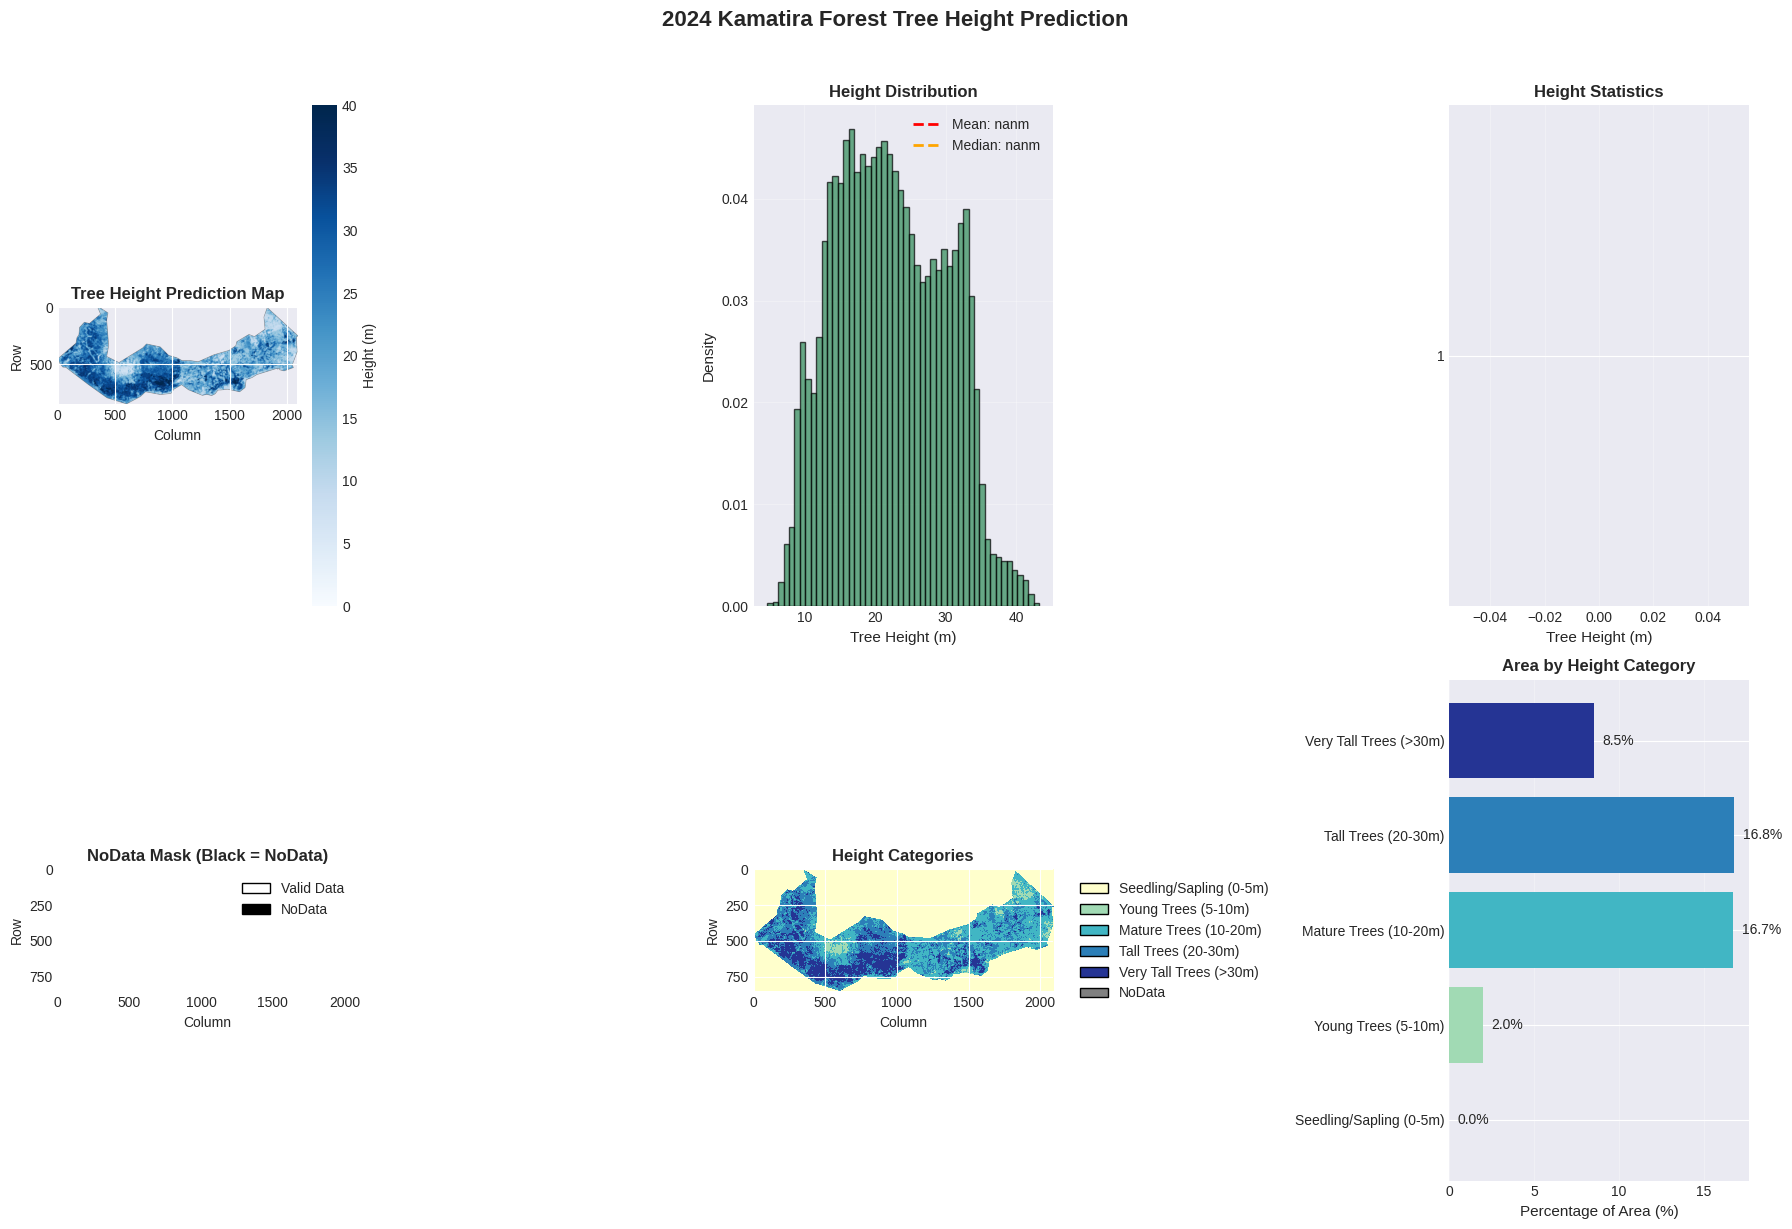


HEIGHT CATEGORY SUMMARY
               Category  Count  Percentage  Mean Height
Seedling/Sapling (0-5m)     14         0.0         4.89
    Young Trees (5-10m)  34997         2.0         8.89
  Mature Trees (10-20m) 297520        16.7        15.57
    Tall Trees (20-30m) 298924        16.8        24.66
 Very Tall Trees (>30m) 151702         8.5        33.25


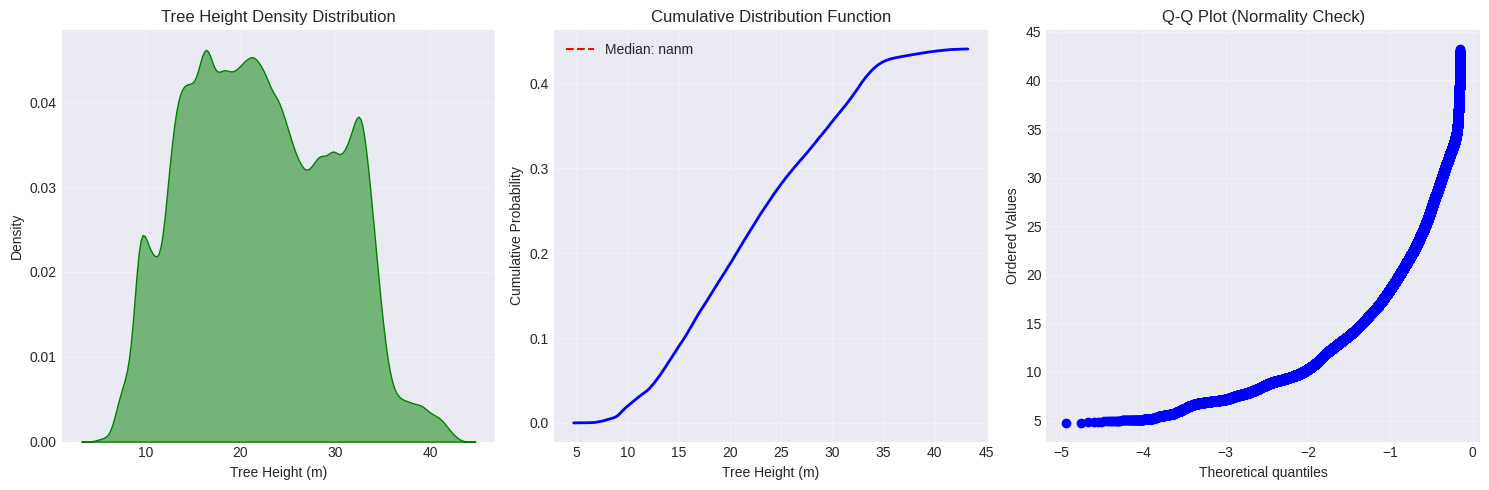


DETAILED STATISTICAL ANALYSIS

📊 Distribution Statistics:
   Skewness: nan
   Kurtosis: nan
   Kolmogorov-Smirnov test p-value: nan

🌳 Forest Structure Analysis:
   Short (2-5m): 14 pixels (0.0%), Avg: 4.9m
   Medium (5-10m): 34,997 pixels (2.0%), Avg: 8.9m
   Tall (10-15m): 124,581 pixels (7.0%), Avg: 12.9m
   Very Tall (15-20m): 172,939 pixels (9.7%), Avg: 17.5m
   Extremely Tall (20-30m): 298,924 pixels (16.8%), Avg: 24.7m
   Giant (>30m): 151,702 pixels (8.5%), Avg: 33.2m

🌿 Biomass Estimation (Approximate):
   Average height: nanm
   Estimated biomass: nan tonnes
   Biomass per hectare: nan kg/ha

 Statistics saved to: /content/drive/MyDrive/Kamatira Model Data/height_prediction_stats.json


In [ ]:
# ============================================================================
# VISUALIZE THE 2024 TREE HEIGHT PREDICTION RASTER
# ============================================================================

import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

def load_and_visualize_height_raster(raster_path, title="2024 Tree Height Prediction"):
    """
    Load and visualize the predicted height raster with NoData masking
    """
    print(f"Loading raster from: {raster_path}")

    try:
        with rasterio.open(raster_path) as src:
            # Read the data
            height_data = src.read(1)

            # Get metadata
            print(f"\n📊 Raster Information:")
            print(f"   Dimensions: {height_data.shape}")
            print(f"   Data type: {height_data.dtype}")
            print(f"   NoData value: {src.nodata}")
            print(f"   CRS: {src.crs}")
            print(f"   Bounds: {src.bounds}")
            print(f"   Resolution: {src.res}")

            # Create a mask for NoData values
            if src.nodata is not None:
                mask = height_data == src.nodata
            else:
                # If no nodata specified, mask NaN values
                mask = np.isnan(height_data)

            print(f"\n📈 Data Statistics:")
            print(f"   Total pixels: {height_data.size:,}")
            print(f"   NoData pixels: {np.sum(mask):,} ({np.sum(mask)/height_data.size*100:.1f}%)")
            print(f"   Valid pixels: {np.sum(~mask):,} ({np.sum(~mask)/height_data.size*100:.1f}%)")

            # Extract valid data
            valid_data = height_data[~mask]

            if len(valid_data) > 0:
                print(f"\n🌳 Tree Height Statistics (valid pixels only):")
                print(f"   Min height: {np.min(valid_data):.2f}m")
                print(f"   Max height: {np.max(valid_data):.2f}m")
                print(f"   Mean height: {np.mean(valid_data):.2f}m")
                print(f"   Median height: {np.median(valid_data):.2f}m")
                print(f"   Std height: {np.std(valid_data):.2f}m")

                # Percentiles
                percentiles = [5, 25, 50, 75, 95]
                print(f"\n📊 Height Distribution Percentiles:")
                for p in percentiles:
                    value = np.percentile(valid_data, p)
                    print(f"   {p}th percentile: {value:.2f}m")

                # Area calculation (assuming 30m resolution)
                pixel_area_m2 = 30 * 30
                total_area_km2 = (len(valid_data) * pixel_area_m2) / 1_000_000
                print(f"\n🗺️  Area Coverage:")
                print(f"   Total predicted area: {total_area_km2:.2f} km²")

            # Create masked array for visualization
            masked_data = np.ma.masked_where(mask, height_data)

            # Create custom colormap for tree heights
            colors = ['#f7fbff', '#deebf7', '#c6dbef', '#9ecae1', '#6baed6',
                     '#4292c6', '#2171b5', '#08519c', '#08306b', '#00264d']
            cmap = LinearSegmentedColormap.from_list('tree_height', colors, N=256)

            # Create figure
            fig, axes = plt.subplots(2, 3, figsize=(18, 12))
            fig.suptitle(title, fontsize=16, fontweight='bold', y=1.02)

            # Plot 1: Main height map
            im1 = axes[0, 0].imshow(masked_data, cmap=cmap, vmin=0, vmax=40)
            axes[0, 0].set_title('Tree Height Prediction Map', fontsize=12, fontweight='bold')
            axes[0, 0].set_xlabel('Column')
            axes[0, 0].set_ylabel('Row')
            plt.colorbar(im1, ax=axes[0, 0], label='Height (m)')

            # Plot 2: Histogram of heights
            axes[0, 1].hist(valid_data, bins=50, edgecolor='black', alpha=0.7,
                           color='#2E8B57', density=True)
            axes[0, 1].axvline(np.mean(valid_data), color='red', linestyle='--',
                              linewidth=2, label=f'Mean: {np.mean(valid_data):.1f}m')
            axes[0, 1].axvline(np.median(valid_data), color='orange', linestyle='--',
                              linewidth=2, label=f'Median: {np.median(valid_data):.1f}m')
            axes[0, 1].set_xlabel('Tree Height (m)', fontsize=11)
            axes[0, 1].set_ylabel('Density', fontsize=11)
            axes[0, 1].set_title('Height Distribution', fontsize=12, fontweight='bold')
            axes[0, 1].legend()
            axes[0, 1].grid(True, alpha=0.3)

            # Plot 3: Box plot
            bp = axes[0, 2].boxplot(valid_data, vert=False, patch_artist=True)
            bp['boxes'][0].set_facecolor('#2E8B57')
            bp['medians'][0].set_color('red')
            axes[0, 2].set_xlabel('Tree Height (m)', fontsize=11)
            axes[0, 2].set_title('Height Statistics', fontsize=12, fontweight='bold')
            axes[0, 2].grid(True, alpha=0.3, axis='x')

            # Plot 4: Spatial distribution of NoData
            axes[1, 0].imshow(mask, cmap='gray_r', interpolation='nearest')
            axes[1, 0].set_title('NoData Mask (Black = NoData)', fontsize=12, fontweight='bold')
            axes[1, 0].set_xlabel('Column')
            axes[1, 0].set_ylabel('Row')

            # Add legend for mask
            legend_elements = [Patch(facecolor='white', edgecolor='black', label='Valid Data'),
                             Patch(facecolor='black', edgecolor='black', label='NoData')]
            axes[1, 0].legend(handles=legend_elements, loc='upper right')

            # Plot 5: Height categories (classified map)
            # Define height categories
            height_categories = {
                'Seedling/Sapling (0-5m)': (0, 5),
                'Young Trees (5-10m)': (5, 10),
                'Mature Trees (10-20m)': (10, 20),
                'Tall Trees (20-30m)': (20, 30),
                'Very Tall Trees (>30m)': (30, np.inf)
            }

            # Create classified raster
            classified = np.zeros_like(height_data, dtype=int)
            classified[mask] = -1  # NoData

            category_colors = ['#ffffcc', '#a1dab4', '#41b6c4', '#2c7fb8', '#253494']

            for idx, (category, (low, high)) in enumerate(height_categories.items()):
                category_mask = (~mask) & (height_data >= low) & (height_data < high)
                classified[category_mask] = idx

            # Plot classified map
            cmap_class = mcolors.ListedColormap(category_colors)
            bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
            norm = mcolors.BoundaryNorm(bounds, cmap_class.N)

            im5 = axes[1, 1].imshow(classified, cmap=cmap_class, norm=norm, interpolation='nearest')
            axes[1, 1].set_title('Height Categories', fontsize=12, fontweight='bold')
            axes[1, 1].set_xlabel('Column')
            axes[1, 1].set_ylabel('Row')

            # Create custom legend for categories
            legend_elements = [Patch(facecolor=color, edgecolor='black', label=cat)
                             for cat, color in zip(height_categories.keys(), category_colors)]
            legend_elements.append(Patch(facecolor='gray', edgecolor='black', label='NoData'))
            axes[1, 1].legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')

            # Plot 6: Height statistics by category
            if len(valid_data) > 0:
                category_stats = []
                for category, (low, high) in height_categories.items():
                    category_data = valid_data[(valid_data >= low) & (valid_data < high)]
                    if len(category_data) > 0:
                        category_stats.append({
                            'Category': category,
                            'Count': len(category_data),
                            'Percentage': len(category_data)/len(valid_data)*100,
                            'Mean Height': np.mean(category_data)
                        })

                if category_stats:
                    stats_df = pd.DataFrame(category_stats)
                    bars = axes[1, 2].barh(range(len(stats_df)), stats_df['Percentage'],
                                          color=category_colors[:len(stats_df)])
                    axes[1, 2].set_yticks(range(len(stats_df)))
                    axes[1, 2].set_yticklabels(stats_df['Category'])
                    axes[1, 2].set_xlabel('Percentage of Area (%)', fontsize=11)
                    axes[1, 2].set_title('Area by Height Category', fontsize=12, fontweight='bold')
                    axes[1, 2].grid(True, alpha=0.3, axis='x')

                    # Add percentage labels
                    for i, (bar, percentage) in enumerate(zip(bars, stats_df['Percentage'])):
                        axes[1, 2].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                                       f'{percentage:.1f}%', va='center')

            plt.tight_layout()
            plt.show()

            # Print summary table
            print("\n" + "="*80)
            print("HEIGHT CATEGORY SUMMARY")
            print("="*80)

            if category_stats:
                summary_df = pd.DataFrame(category_stats)
                summary_df = summary_df[['Category', 'Count', 'Percentage', 'Mean Height']]
                summary_df['Percentage'] = summary_df['Percentage'].round(1)
                summary_df['Mean Height'] = summary_df['Mean Height'].round(2)
                print(summary_df.to_string(index=False))

            return masked_data, valid_data

    except Exception as e:
        print(f"Error loading raster: {e}")
        return None, None

# ============================================================================
# LOAD AND VISUALIZE THE PREDICTED HEIGHT RASTER
# ============================================================================

# Path to your predicted height raster
prediction_path = "/content/drive/MyDrive/Kamatira Model Data/Tree_Height_2024_Predicted.tif"

# Load and visualize
masked_heights, valid_heights = load_and_visualize_height_raster(
    prediction_path,
    title="2024 Kamatira Forest Tree Height Prediction"
)

# ============================================================================
# ADDITIONAL VISUALIZATIONS
# ============================================================================

if valid_heights is not None and len(valid_heights) > 0:
    # Create additional detailed visualizations
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Plot 1: Density plot with KDE
    sns.kdeplot(valid_heights, ax=axes[0], fill=True, color='green', alpha=0.5)
    axes[0].set_xlabel('Tree Height (m)')
    axes[0].set_ylabel('Density')
    axes[0].set_title('Tree Height Density Distribution')
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Cumulative distribution
    sorted_heights = np.sort(valid_heights)
    cdf = np.arange(1, len(sorted_heights) + 1) / len(sorted_heights)
    axes[1].plot(sorted_heights, cdf, linewidth=2, color='blue')
    axes[1].set_xlabel('Tree Height (m)')
    axes[1].set_ylabel('Cumulative Probability')
    axes[1].set_title('Cumulative Distribution Function')
    axes[1].grid(True, alpha=0.3)

    # Add median line
    median_height = np.median(valid_heights)
    axes[1].axvline(median_height, color='red', linestyle='--',
                   label=f'Median: {median_height:.1f}m')
    axes[1].legend()

    # Plot 3: QQ plot for normality check
    from scipy import stats
    stats.probplot(valid_heights, dist="norm", plot=axes[2])
    axes[2].set_title('Q-Q Plot (Normality Check)')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print detailed statistics
    print("\n" + "="*80)
    print("DETAILED STATISTICAL ANALYSIS")
    print("="*80)

    # Skewness and Kurtosis
    from scipy.stats import skew, kurtosis

    print(f"\n📊 Distribution Statistics:")
    print(f"   Skewness: {skew(valid_heights):.3f}")
    print(f"   Kurtosis: {kurtosis(valid_heights):.3f}")

    # Test for normality
    from scipy.stats import shapiro
    if len(valid_heights) > 5000:
        # For large datasets, use Kolmogorov-Smirnov test
        from scipy.stats import kstest
        ks_stat, ks_p = kstest((valid_heights - np.mean(valid_heights))/np.std(valid_heights), 'norm')
        print(f"   Kolmogorov-Smirnov test p-value: {ks_p:.4f}")
    else:
        # For smaller datasets, use Shapiro-Wilk
        shapiro_stat, shapiro_p = shapiro(valid_heights)
        print(f"   Shapiro-Wilk test p-value: {shapiro_p:.4f}")

    # Calculate area in different height categories
    print(f"\n🌳 Forest Structure Analysis:")

    # More detailed categories
    detailed_categories = {
        'Very Short (0-2m)': (0, 2),
        'Short (2-5m)': (2, 5),
        'Medium (5-10m)': (5, 10),
        'Tall (10-15m)': (10, 15),
        'Very Tall (15-20m)': (15, 20),
        'Extremely Tall (20-30m)': (20, 30),
        'Giant (>30m)': (30, np.inf)
    }

    for category, (low, high) in detailed_categories.items():
        count = np.sum((valid_heights >= low) & (valid_heights < high))
        percentage = count / len(valid_heights) * 100
        if count > 0:
            mean_height = np.mean(valid_heights[(valid_heights >= low) & (valid_heights < high)])
            print(f"   {category}: {count:,} pixels ({percentage:.1f}%), Avg: {mean_height:.1f}m")

    # Calculate biomass estimation (simplified)
    # Assuming average biomass of 200 kg per cubic meter of tree volume
    # Very rough estimation: volume ≈ height × basal_area
    print(f"\n🌿 Biomass Estimation (Approximate):")
    avg_height = np.mean(valid_heights)
    total_pixels = len(valid_heights)
    pixel_area_ha = (30 * 30) / 10000  # Convert to hectares

    # Very rough biomass estimation formula (simplified)
    biomass_per_ha = avg_height * 50  # kg/ha (simplified)
    total_biomass_kg = biomass_per_ha * total_pixels * pixel_area_ha
    total_biomass_tonnes = total_biomass_kg / 1000

    print(f"   Average height: {avg_height:.1f}m")
    print(f"   Estimated biomass: {total_biomass_tonnes:,.0f} tonnes")
    print(f"   Biomass per hectare: {biomass_per_ha:.0f} kg/ha")

    # Save statistics to file
    stats_dict = {
        'total_pixels': int(total_pixels),
        'valid_pixels': int(len(valid_heights)),
        'mean_height': float(np.mean(valid_heights)),
        'median_height': float(np.median(valid_heights)),
        'std_height': float(np.std(valid_heights)),
        'min_height': float(np.min(valid_heights)),
        'max_height': float(np.max(valid_heights)),
        'estimated_area_km2': float(total_pixels * pixel_area_ha / 100),
        'estimated_biomass_tonnes': float(total_biomass_tonnes)
    }

    import json
    with open('/content/drive/MyDrive/Kamatira Model Data/height_prediction_stats.json', 'w') as f:
        json.dump(stats_dict, f, indent=4)

    print(f"\n Statistics saved to: /content/drive/MyDrive/Kamatira Model Data/height_prediction_stats.json")

Batch Process of CHM

In [ ]:
# ============================================================================
# BATCH PROCESS FOR MULTIPLE YEARS - TREE HEIGHT PREDICTION
# ============================================================================

import numpy as np
import rasterio
from rasterio.enums import Resampling
import pandas as pd
import warnings
import os
warnings.filterwarnings('ignore')

def resample_raster_to_match(input_path, target_shape):
    """
    Resample a raster to match target dimensions
    """
    with rasterio.open(input_path) as src:
        # Read the data and resample to target shape
        data = src.read(
            1,
            out_shape=target_shape,
            resampling=Resampling.bilinear  # Good for continuous data
        )

        # Update the transform
        transform = src.transform * src.transform.scale(
            (src.width / target_shape[1]),
            (src.height / target_shape[0])
        )

        profile = src.profile.copy()
        profile.update({
            'height': target_shape[0],
            'width': target_shape[1],
            'transform': transform
        })

        return data, profile

def create_prediction_raster_for_year(raster_paths_dict, trained_rf_model, year_label, output_dir):
    """
    Apply trained RF model to raster data for a specific year
    """
    print(f"\n{'='*60}")
    print(f"PROCESSING YEAR: {year_label}")
    print(f"{'='*60}")

    # Get target dimensions from the first available raster
    first_raster_path = next(iter(raster_paths_dict.values()))

    try:
        with rasterio.open(first_raster_path) as src:
            target_shape = src.shape
            print(f"Target dimensions: {target_shape}")

    except Exception as e:
        print(f"Error reading reference raster: {e}")
        return None

    raster_data = {}
    profiles = {}

    for name, path in raster_paths_dict.items():
        try:
            with rasterio.open(path) as src:
                if src.shape == target_shape:
                    # Already correct size
                    raster_data[name] = src.read(1)
                    profiles[name] = src.profile
                    print(f"✓ Loaded {name}: {raster_data[name].shape}")
                else:
                    # Need to resample
                    print(f"↻ Resampling {name}: {src.shape} → {target_shape}")
                    resampled_data, profile = resample_raster_to_match(path, target_shape)
                    raster_data[name] = resampled_data
                    profiles[name] = profile
                    print(f"✓ Resampled {name}: {resampled_data.shape}")

        except Exception as e:
            print(f"✗ Error loading {name}: {e}")
            return None

    height, width = target_shape
    print(f"Final raster dimensions: {height} x {width}")

    # Create coordinate arrays
    print("Preparing data for prediction...")
    rows, cols = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')

    # Stack all raster values
    data_dict = {
        'row': rows.flatten(),
        'col': cols.flatten()
    }

    for name, data in raster_data.items():
        data_dict[name] = data.flatten()

    # Create DataFrame
    df = pd.DataFrame(data_dict)

    # Remove pixels with NaN values
    original_pixels = len(df)
    df_clean = df.dropna()
    valid_pixels = len(df_clean)

    print(f"Original pixels: {original_pixels:,}")
    print(f"Valid pixels (no NaN): {valid_pixels:,}")
    print(f"Invalid pixels: {original_pixels - valid_pixels:,}")

    if valid_pixels == 0:
        print("No valid pixels found!")
        return None

    # Get the feature names that the model was trained with
    if hasattr(trained_rf_model, 'feature_names_in_'):
        model_features = list(trained_rf_model.feature_names_in_)
        print(f"Model was trained with features: {model_features}")
    else:
        # Default feature order (adjust based on your training)
        model_features = ['NDVI_24_25', 'EVI_24_25', 'LAI_24_25', 'Rain_24_25', 'Slope', 'DEM']
        print(f"Using default feature order: {model_features}")

    # CRITICAL FIX: Map the raster names to model feature names
    # We need to extract the base feature name (e.g., NDVI, EVI, etc.)
    # and ignore the year suffix

    # Create a mapping from base feature name to actual raster column name
    feature_mapping = {}

    # First, handle static features (Slope and DEM)
    for model_feat in model_features:
        if model_feat == 'Slope':
            # Find Slope raster
            for raster_key in raster_data.keys():
                if 'slope' in raster_key.lower():
                    feature_mapping[model_feat] = raster_key
                    break
        elif model_feat == 'DEM':
            # Find DEM raster
            for raster_key in raster_data.keys():
                if 'dem' in raster_key.lower():
                    feature_mapping[model_feat] = raster_key
                    break
        else:
            # Handle dynamic features (NDVI, EVI, LAI, Rain)
            # Extract base name (remove year suffix)
            base_name = model_feat.split('_')[0]  # e.g., 'NDVI' from 'NDVI_24_25'

            # Find matching raster
            for raster_key in raster_data.keys():
                if base_name.lower() in raster_key.lower():
                    feature_mapping[model_feat] = raster_key
                    break

    print("\nFeature mapping:")
    for model_feat, raster_key in feature_mapping.items():
        print(f"  {model_feat} → {raster_key}")

    # Check if all required features are present
    missing_features = set(model_features) - set(feature_mapping.keys())
    if missing_features:
        print(f"\n❌ Missing features in mapping: {missing_features}")
        print("Available raster columns:", list(raster_data.keys()))
        return None

    # Ensure the DataFrame columns are in the exact same order as during training
    try:
        X_pred = df_clean[[feature_mapping[feat] for feat in model_features]]

        # Rename columns to match model's expected feature names
        X_pred.columns = model_features

        print(f"\n✅ All features mapped successfully!")
        print("Data shape for prediction:", X_pred.shape)

    except KeyError as e:
        print(f"\n❌ Error in feature mapping: {e}")
        print("Available columns in df_clean:", df_clean.columns.tolist())
        return None

    # Make predictions
    print("\nMaking predictions...")
    predictions = trained_rf_model.predict(X_pred)

    # Create output raster
    print("Creating output raster...")
    height_raster = np.full((height, width), np.nan, dtype=np.float32)

    # Place predictions back in raster format
    valid_rows = df_clean['row'].values
    valid_cols = df_clean['col'].values
    height_raster[valid_rows, valid_cols] = predictions

    # Save the output raster
    output_filename = f"Tree_Height_{year_label}_Predicted.tif"
    output_path = os.path.join(output_dir, output_filename)

    # Use profile from reference raster
    output_profile = profiles[list(profiles.keys())[0]].copy()
    output_profile.update({
        'dtype': 'float32',
        'count': 1,
        'nodata': np.nan,
        'compress': 'lzw'
    })

    print(f"Saving height prediction raster to: {output_path}")
    with rasterio.open(output_path, 'w', **output_profile) as dst:
        dst.write(height_raster, 1)

    print("✓ Height prediction raster created successfully!")

    # Print statistics
    valid_predictions = height_raster[~np.isnan(height_raster)]
    if len(valid_predictions) > 0:
        print(f"\n📊 {year_label} Prediction Statistics:")
        print(f"   Min height: {np.min(valid_predictions):.2f}m")
        print(f"   Max height: {np.max(valid_predictions):.2f}m")
        print(f"   Mean height: {np.mean(valid_predictions):.2f}m")
        print(f"   Std height: {np.std(valid_predictions):.2f}m")
        print(f"   Valid pixels: {len(valid_predictions):,}")

        # Calculate percentiles
        percentiles = [5, 25, 50, 75, 95]
        print(f"\n📈 Height Distribution Percentiles:")
        for p in percentiles:
            value = np.percentile(valid_predictions, p)
            print(f"   {p}th percentile: {value:.2f}m")

    return height_raster

# ============================================================================
# MAIN BATCH PROCESSING SCRIPT
# ============================================================================

def main():
    # Create output directory
    output_dir = "/content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled"
    os.makedirs(output_dir, exist_ok=True)

    # Use the RF model from your ensemble results (already in memory)
    try:
        rf_model = results['Random Forest']['model']
        print(f"✓ Loaded Random Forest model from ensemble results")

        # Check model features
        if hasattr(rf_model, 'feature_names_in_'):
            print(f"Model was trained with features: {list(rf_model.feature_names_in_)}")
        else:
            print("Model feature names not available - using default mapping")

    except Exception as e:
        print(f"❌ Error accessing model: {e}")
        print("\nTrying to load from file...")
        try:
            import joblib
            rf_model = joblib.load('/content/drive/MyDrive/Kamatira Model Data/Models/RandomForest_H_Model_1.pkl')
            print("✓ Model loaded from file")
        except:
            print("❌ Could not load model")
            return

    # Define raster paths for all years (updated to match your paths)
    years_data = {
        "2024_2025": {
            "NDVI_24_25": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2024_2025_resampled.tif",
            "EVI_24_25": "/content/drive/MyDrive/Kamatira Model Data/EVI_2024_2025_resampled.tif",
            "Rain_24_25": "/content/drive/MyDrive/Kamatira Model Data/Rainfall_2024_2025_resampled.tif",
            "LAI_24_25": "/content/drive/MyDrive/Kamatira Model Data/LAI_2024_2025.tif",
            "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
            "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
        },
        "2019_2020": {
            "NDVI_19_20": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2019_2020_resampled.tif",
            "EVI_19_20": "/content/drive/MyDrive/Kamatira Model Data/EVI_2019_2020_resampled.tif",
            "Rain_19_20": "/content/drive/MyDrive/Kamatira Model Data/Rainfall_2019_2020_resampled.tif",
            "LAI_19_20": "/content/drive/MyDrive/Kamatira Model Data/LAI_2019_2020.tif",
            "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
            "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
        },
        "2014_2015": {
            "NDVI_14_15": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2014_2015_resampled.tif",
            "EVI_14_15": "/content/drive/MyDrive/Kamatira Model Data/EVI_2014_2015_resampled.tif",
            "Rain_14_15": "/content/drive/MyDrive/Kamatira Model Data/Rainfall_2014_2015_resampled.tif",
            "LAI_14_15": "/content/drive/MyDrive/Kamatira Model Data/LAI_2014_2015.tif",
            "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
            "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
        },
        "2009_2010": {
            "NDVI_09_10": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2009_2010.tif",
            "EVI_09_10": "/content/drive/MyDrive/Kamatira Model Data/EVI_2009_2010.tif",
            "Rain_09_10": "/content/drive/MyDrive/Kamatira Model Data/Precip_2010.tif",
            "LAI_09_10": "/content/drive/MyDrive/Kamatira Model Data/LAI_2009_2010.tif",
            "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
            "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
        },
        "2004_2005": {
            "NDVI_04_05": "/content/drive/MyDrive/Kamatira Model Data/NDVI_2004_2004.tif",
            "EVI_04_05": "/content/drive/MyDrive/Kamatira Model Data/EVI_2004_2004.tif",
            "Rain_04_05": "/content/drive/MyDrive/Kamatira Model Data/Precip_2005.tif",
            "LAI_04_05": "/content/drive/MyDrive/Kamatira Model Data/LAI_2004_2004.tif",
            "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
            "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
        },
        "1999_2000": {
            "NDVI_99_00": "/content/drive/MyDrive/Kamatira Model Data/NDVI_1999_2000.tif",
            "EVI_99_00": "/content/drive/MyDrive/Kamatira Model Data/EVI_1999_2000.tif",
            "Rain_99_00": "/content/drive/MyDrive/Kamatira Model Data/Precip_2000.tif",
            "LAI_99_00": "/content/drive/MyDrive/Kamatira Model Data/LAI_1999_2000.tif",
            "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
            "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
        },
        "1994_1995": {
            "NDVI_94_95": "/content/drive/MyDrive/Kamatira Model Data/NDVI_1994_1995.tif",
            "EVI_94_95": "/content/drive/MyDrive/Kamatira Model Data/EVI_1994_1995.tif",
            "Rain_94_95": "/content/drive/MyDrive/Kamatira Model Data/Precip_1995.tif",
            "LAI_94_95": "/content/drive/MyDrive/Kamatira Model Data/LAI_1994_1995.tif",
            "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
            "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
        },
        "1989_1990": {
            "NDVI_89_90": "/content/drive/MyDrive/Kamatira Model Data/NDVI_1989_1990.tif",
            "EVI_89_90": "/content/drive/MyDrive/Kamatira Model Data/EVI_1989_1990.tif",
            "Rain_89_90": "/content/drive/MyDrive/Kamatira Model Data/Precip1990.tif",
            "LAI_89_90": "/content/drive/MyDrive/Kamatira Model Data/LAI_1989_1990.tif",
            "Slope": "/content/drive/MyDrive/Kamatira Model Data/reprojected_Slope.tif",
            "DEM": "/content/drive/MyDrive/Kamatira Model Data/reprojected_DEM.tif"
        }
    }

    # Process each year
    successful_years = []
    failed_years = []

    for year_label, raster_paths in years_data.items():
        try:
            print(f"\n{'='*60}")
            print(f"STARTING: {year_label}")
            print(f"{'='*60}")

            height_raster = create_prediction_raster_for_year(
                raster_paths,
                rf_model,
                year_label,
                output_dir
            )

            if height_raster is not None:
                successful_years.append(year_label)
                print(f"\n✅ SUCCESS: {year_label}")
            else:
                failed_years.append(year_label)
                print(f"\n❌ FAILED: {year_label}")

        except Exception as e:
            print(f"\n❌ ERROR processing {year_label}: {e}")
            import traceback
            traceback.print_exc()
            failed_years.append(year_label)

    # Print summary
    print(f"\n{'='*60}")
    print("BATCH PROCESSING SUMMARY")
    print(f"{'='*60}")
    print(f"Successful years: {len(successful_years)}")
    print(f"Failed years: {len(failed_years)}")

    if successful_years:
        print("\n✅ Successful:")
        for year in successful_years:
            print(f"   - {year}")

    if failed_years:
        print("\n❌ Failed:")
        for year in failed_years:
            print(f"   - {year}")

    print(f"\nOutput directory: {output_dir}")

# ============================================================================
# RUN THE BATCH PROCESSING
# ============================================================================

if __name__ == "__main__":
    print("Starting batch processing for all years...")
    print("Model features:", results['Random Forest']['model'].feature_names_in_)
    main()

Starting batch processing for all years...
Model features: ['NDVI_24_25' 'EVI_24_25' 'LAI_24_25' 'Rain_24_25' 'Slope' 'DEM']
✓ Loaded Random Forest model from ensemble results
Model was trained with features: ['NDVI_24_25', 'EVI_24_25', 'LAI_24_25', 'Rain_24_25', 'Slope', 'DEM']

STARTING: 2024_2025

PROCESSING YEAR: 2024_2025
Target dimensions: (851, 2089)
✓ Loaded NDVI_24_25: (851, 2089)
✓ Loaded EVI_24_25: (851, 2089)
✓ Loaded Rain_24_25: (851, 2089)
✓ Loaded LAI_24_25: (851, 2089)
↻ Resampling Slope: (427, 1045) → (851, 2089)
✓ Resampled Slope: (851, 2089)
↻ Resampling DEM: (427, 1045) → (851, 2089)
✓ Resampled DEM: (851, 2089)
Final raster dimensions: 851 x 2089
Preparing data for prediction...
Original pixels: 1,777,739
Valid pixels (no NaN): 783,157
Invalid pixels: 994,582
Model was trained with features: ['NDVI_24_25', 'EVI_24_25', 'LAI_24_25', 'Rain_24_25', 'Slope', 'DEM']

Feature mapping:
  NDVI_24_25 → NDVI_24_25
  EVI_24_25 → EVI_24_25
  LAI_24_25 → LAI_24_25
  Rain_24_25 

Extracted raster saved at: /content/drive/MyDrive/Kamatira Model Data/Outputs/Revised_H_Predicted_2000_Masked.tif


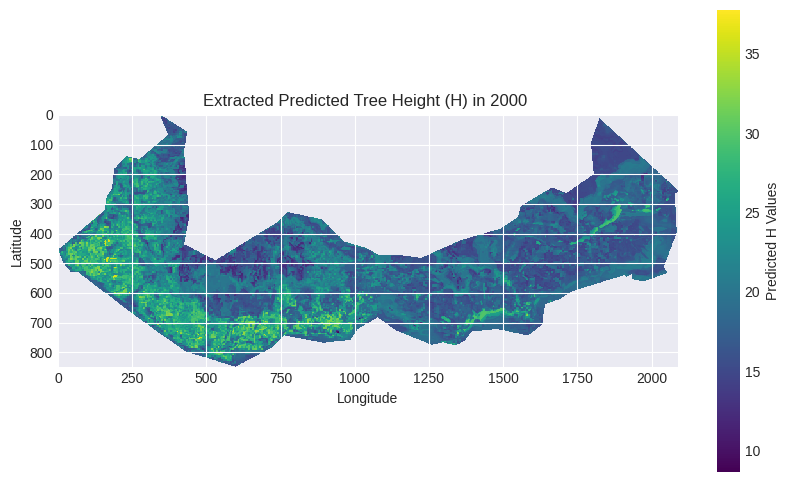

In [ ]:
import rasterio
import rasterio.mask
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import mapping

# Paths to files
raster_path = "/content/drive/MyDrive/Kamatira Model Data/Outputs/Remodelled/Tree_Height_1999_2000_Predicted.tif"
mask_path = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"
output_extracted_raster = "/content/drive/MyDrive/Kamatira Model Data/Outputs/Revised_H_Predicted_2000_Masked.tif"

# Load the vector mask
gdf_mask = gpd.read_file(mask_path)

# Open the raster and mask it using the geojson file
with rasterio.open(raster_path) as src:
    out_image, out_transform = rasterio.mask.mask(src, [mapping(geom) for geom in gdf_mask.geometry], crop=True)
    out_meta = src.meta.copy()
    nodata_value = src.nodata  # Store NoData value

# Update metadata after cropping
out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

# Save the masked raster
with rasterio.open(output_extracted_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("Extracted raster saved at:", output_extracted_raster)

# --- VISUALIZATION ---
# Mask NoData values
masked_data = np.ma.masked_where(out_image[0] == nodata_value, out_image[0])

# Create an alpha transparency mask
alpha_mask = np.where(out_image[0] == nodata_value, 0, 1)

# Plot the masked raster
plt.figure(figsize=(10, 6))
plt.imshow(masked_data, cmap="viridis", interpolation="nearest", alpha=alpha_mask)
plt.colorbar(label="Predicted H Values")
plt.title("Extracted Predicted Tree Height (H) in 2000 ")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()
